# Part I: From VGG to ResNet [30 pts]
Implement and compare VGG-16 (Version C) and ResNet-18 for image classification. Explore advanced techniques to improve model performance and the transition from standard deep CNNs to networks with residual connections.
The expected accuracy is above 75% for the base model and 80% for the improved model.

## Step 1: Data preparation

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score
)
import time
import pickle
import gc

1. Load CNN dataset.

In [ ]:
data_dir = "/content/cnn_dataset"
classes = ['dogs', 'food', 'vehicles']

transform_tensor = transforms.Compose([
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform_tensor)

Analyze the dataset.

In [ ]:
class_counts = {class_name: len(os.listdir(os.path.join(data_dir, class_name))) for class_name in classes}
print("Dataset Statistics:", class_counts)

Dataset Statistics: {'dogs': 10000, 'food': 10000, 'vehicles': 10000}


2.	Create at least three different visualizations to explore the dataset. Provide a short description explaining what each visualization shows.

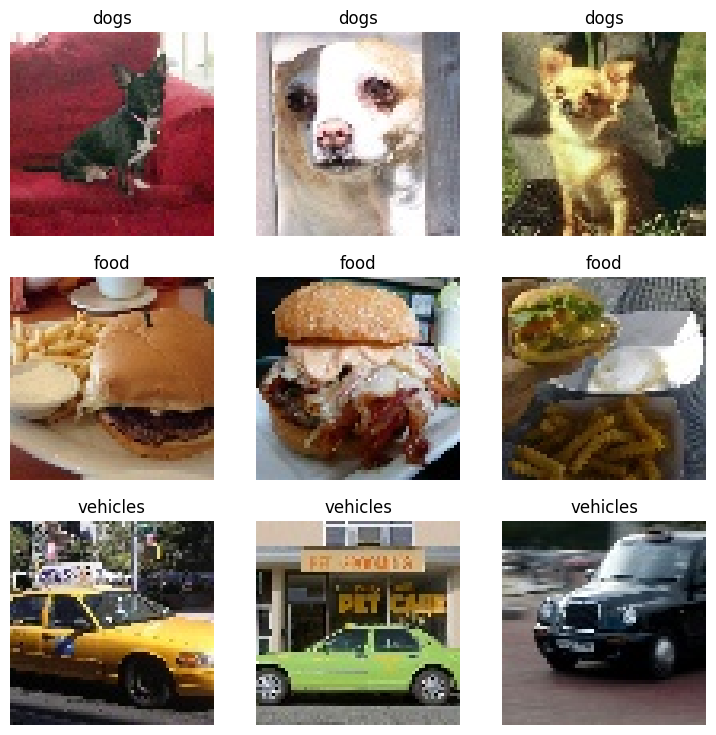

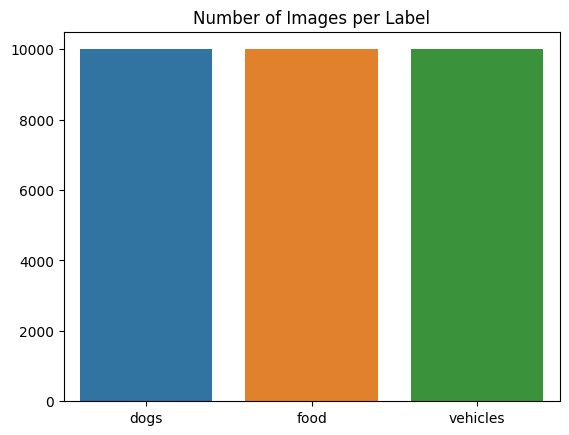

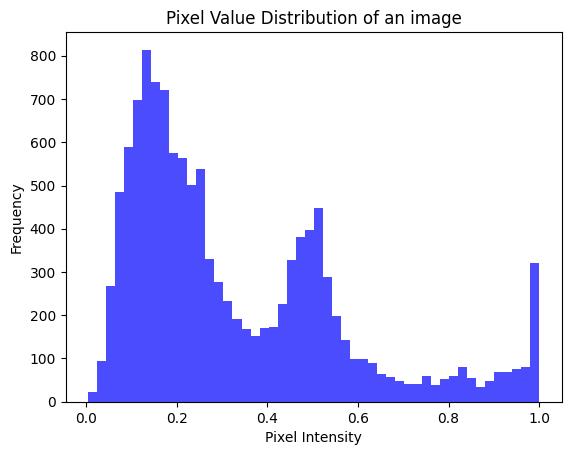

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(9, 9))
for i, class_name in enumerate(classes):
    class_indices = [idx for idx, (_, label) in enumerate(dataset) if label == i]
    sample_images = [dataset[idx][0].permute(1, 2, 0).numpy() for idx in class_indices[:3]]
    for j, img in enumerate(sample_images):
        axes[i, j].imshow(img)
        axes[i, j].set_title(classes[i])
        axes[i, j].axis('off')
plt.show()

# Bar chart of class distribution
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title("Number of Images per Label")
plt.show()

sample_img = dataset[0][0].numpy().flatten()
plt.hist(sample_img, bins=50, color='blue', alpha=0.7)
plt.title("Pixel Value Distribution of an image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

3. Preprocess the dataset.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform)

4. Split the dataset into training, testing, and validation sets.

In [ ]:
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
print(train_size, val_size, test_size)

# Create DataLoaders
def get_dataloader(dataset, batch_size=32):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

dataloaders = {
    'train_32': get_dataloader(train_dataset, batch_size=32),
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_32': get_dataloader(val_dataset, batch_size=32),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_32': get_dataloader(test_dataset, batch_size=32),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

21000 4500 4500


## Step 2: Implementing VGG

1. Implement the VGG-16 (Version C) architecture.

In [15]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [ ]:
class VGG13_C(nn.Module):
    def __init__(self, num_classes=3,drop=0):
        super(VGG13_C, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(True),
            nn.Dropout(drop),
            nn.Linear(4096, 4096),
            nn.ReLU(True),
            nn.Linear(4096, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

sample_model = VGG13_C(drop=0.5).to(device)
print(sample_model)

VGG13_C(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(1, 1), stride=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=

2. Use dropout and learning rate scheduler. Experiment with weight initialization strategies.

In [ ]:
drop = 0.5
schedular = False

3. Train your VGG-16 model.

In [ ]:
def test_model(model: torch.nn.Module, dataloader: torch.utils.data.DataLoader, device: torch.device, criterion) -> tuple:
    model.eval()
    test_loss, correct_test = 0.0, 0
    test_predictions, labels_test_total, test_probabilities = [], [], []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            test_output = model(inputs)
            loss = criterion(test_output, labels)
            test_loss += loss.item()

            probs = F.softmax(test_output, dim=1)
            preds = torch.argmax(probs, dim=1)

            correct_test += (preds == labels).sum().item()
            test_predictions.extend(preds.tolist())
            labels_test_total.extend(labels.tolist())
            test_probabilities.extend(probs.tolist())

    test_loss /= len(dataloader)
    test_accuracy = 100 * correct_test / len(dataloader.dataset)

    print(f"Test Accuracy: {test_accuracy:.2f}%")
    print(f"Test Loss: {test_loss:.4f}")

    return torch.tensor(labels_test_total), torch.tensor(test_predictions), torch.tensor(test_probabilities), test_loss, test_accuracy

In [ ]:
def train_and_validate(
    model: torch.nn.Module,
    train_loader: torch.utils.data.DataLoader,
    val_loader: torch.utils.data.DataLoader,
    device: torch.device,
    num_epochs: int,
    optimizer: torch.optim.Optimizer,
    criterion,
    l2_scheduler: bool = False,
    early_stopping: int = None,
):
    train_losses, train_accuracies = [], []
    validation_losses, validation_accuracies = [], []
    epoch_times = []
    best_val_accuracy = 0.0
    epochs_without_improvement, train_predicted_true = 0,0
    start_time = time.time()

    gc.collect()
    torch.cuda.empty_cache()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        model.train()

        train_loss, train_predicted_true, correct_train, total_train = 0.0, 0, 0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if l2_scheduler:
                l2_loss = sum(p.pow(2.0).sum() for p in model.parameters())
                loss += 5e-4 * l2_loss

            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            probs = F.softmax(outputs, dim=1)
            predicted = torch.argmax(probs, dim=1)
            train_predicted_true += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_losses.append(train_loss / len(train_loader))
        train_accuracies.append(train_predicted_true / total_train)

        model.eval()
        val_loss, correct_val, total_val = 0.0, 0, 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item()
                probs = F.softmax(outputs, dim=1)
                predicted = torch.argmax(probs, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_loss_epoch = val_loss / len(val_loader)
        val_acc_epoch = correct_val / total_val
        validation_losses.append(val_loss_epoch)
        validation_accuracies.append(val_acc_epoch)

        if val_acc_epoch > best_val_accuracy:
            best_val_accuracy = val_acc_epoch
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if early_stopping and epochs_without_improvement >= early_stopping:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        print(f"Epoch {epoch+1}/{num_epochs} - Time: {epoch_time:.2f} sec")
        print(f"Training Loss: {train_losses[-1]:.4f}, Training Accuracy: {train_accuracies[-1]:.4f}")
        print(f"Validation Loss: {validation_losses[-1]:.4f},Validation Accuracy: {validation_accuracies[-1]:.4f}")

    total_time = time.time() - start_time
    avg_epoch_time = sum(epoch_times) / len(epoch_times)

    print(f"\nTotal Training Time: {total_time:.2f} seconds ({total_time/60:.2f} minutes)")
    print(f"Average Time per Epoch: {avg_epoch_time:.2f} seconds")

    return train_losses, train_accuracies, validation_losses, validation_accuracies

In [ ]:
def convert_to_numpy(tensor):
    return tensor.cpu().numpy() if isinstance(tensor, torch.Tensor) else np.array(tensor)

def plot_metric_curve(train_values, val_values, test_value, xlabel, ylabel, title, legend_labels):
    plt.figure(figsize=(12, 5))
    plt.plot(train_values, label=legend_labels[0])
    plt.plot(val_values, label=legend_labels[1])
    plt.axhline(y=test_value, color='r', linestyle='--', label=legend_labels[2])
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

def metrics(
    labels_test_total, predicted_test_classes, test_probabilities,
    test_loss, train_losses, train_accuracies, validation_losses, validation_accuracies
):
    labels_test_np = convert_to_numpy(labels_test_total)
    predicted_test_np = convert_to_numpy(predicted_test_classes)

    accuracy = accuracy_score(labels_test_np, predicted_test_np)
    classify_report = classification_report(labels_test_np, predicted_test_np)

    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:\n", classify_report)

    plot_metric_curve(train_losses, validation_losses, test_loss,
                      xlabel='Epoch', ylabel='Loss', title='Loss Curve',
                      legend_labels=['Training Loss', 'Validation Loss', 'Test Loss'])

    plot_metric_curve( train_accuracies, validation_accuracies, accuracy,
                      xlabel='Epoch', ylabel='Accuracy', title='Accuracy Curve',
                      legend_labels=['Train Accuracy', 'Validation Accuracy', 'Final Test Accuracy'])

    cm = confusion_matrix(labels_test_np, predicted_test_np)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.tight_layout()
    plt.show()

In [ ]:
def display_misclassified_images(model, test_loader, device, class_names, num_images=5):

    model.eval()
    misclassified_images = []
    true_labels = []
    predicted_labels = []

    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            preds = outputs.argmax(1)

            for i in range(len(labels)):
                if preds[i] != labels[i]:
                    misclassified_images.append(inputs[i].cpu())
                    true_labels.append(labels[i].cpu().item())
                    predicted_labels.append(preds[i].cpu().item())

                if len(misclassified_images) >= num_images:
                    break
            if len(misclassified_images) >= num_images:
                break

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        img = misclassified_images[i].permute(1, 2, 0).numpy()
        true_label = class_names[true_labels[i]]
        pred_label = class_names[predicted_labels[i]]

        axes[i].imshow(img)
        axes[i].set_title(f"True: {true_label}\nPred: {pred_label}", fontsize=10, color='red')
        axes[i].axis("off")

    plt.show()

In [10]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

<h2>Testing Optimizers: Adam, RMSprop & AdamW with batch size 32

In [ ]:
torch.cuda.empty_cache()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Model 1 : Batch size 32, Adam")
model_1 = VGG13_C(drop=drop).to(device)

optimizer = optim.Adam(model_1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses_1, train_accuracies_1, validation_losses_1, validation_accuracies_1 = train_and_validate(
    model=model_1,
    train_loader=dataloaders['train_32'],
    val_loader=dataloaders['val_32'],
    device=device,
    optimizer = optimizer,
    criterion = criterion,
    num_epochs = 3,
    l2_scheduler=schedular)

torch.save(model_1.state_dict(), "/kaggle/working/model_1.pth")
print("Model 1 (Adam) saved")

Model 1 : Batch size 32, Adam
Epoch 1/3 - Time: 313.53 sec
Training Loss: 0.8305, Training Accuracy: 0.6013
Validation Loss: 0.6178,Validation Accuracy: 0.7664
Epoch 2/3 - Time: 326.73 sec
Training Loss: 0.5508, Training Accuracy: 0.7787
Validation Loss: 0.4634,Validation Accuracy: 0.8260
Epoch 3/3 - Time: 327.93 sec
Training Loss: 0.4694, Training Accuracy: 0.8154
Validation Loss: 0.4264,Validation Accuracy: 0.8387

Total Training Time: 968.34 seconds (16.14 minutes)
Average Time per Epoch: 322.73 seconds
Model 1 (Adam) saved


In [ ]:
model_1.load_state_dict(torch.load("/kaggle/working/model_1.pth", weights_only=True))
labels_test_total_1, test_predictions_1, test_probabilities_1, test_loss_1, test_accuracy_1 = test_model(model_1,dataloaders['test_32'],device,criterion)

Test Accuracy: 84.18%
Test Loss: 0.4170


In [ ]:
model_1_values = {
    "labels_test_total": labels_test_total_1,
    "test_predictions": test_predictions_1,
    "test_probabilities": test_probabilities_1.cpu(),
    "test_loss": test_loss_1,
    "train_losses": train_losses_1,
    "train_accuracies": train_accuracies_1,
    "validation_losses": validation_losses_1,
    "validation_accuracies": validation_accuracies_1
}

with open("/kaggle/working/model_1_values.pkl", "wb") as f:
    pickle.dump(model_1_values, f)
print("Variables saved successfully!")

Variables saved successfully!


In [ ]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
dataloaders = {
    'train_32': get_dataloader(train_dataset, batch_size=32),
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_32': get_dataloader(val_dataset, batch_size=32),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_32': get_dataloader(test_dataset, batch_size=32),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

In [ ]:
torch.cuda.empty_cache()

print("Model 2 : Batch size 32, RMSprop")
model_2 = VGG13_C(drop=drop).to(device)

optimizer_2 = torch.optim.RMSprop(model_2.parameters(), lr=0.0001, momentum=0.9, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()

train_losses_2, train_accuracies_2, validation_losses_2, validation_accuracies_2 = train_and_validate(
    model=model_2,
    train_loader=dataloaders['train_32'],
    val_loader=dataloaders['val_32'],
    device=device,
    optimizer=optimizer_2,
    criterion=criterion,
    num_epochs=3,
    l2_scheduler=schedular
)

torch.save(model_2.state_dict(), "/kaggle/working/model_2.pth")
print("Model 2 (RMSprop) saved successfully!")

Model 2 : Batch size 32, RMSprop
Epoch 1/3 - Time: 332.57 sec
Training Loss: 1.0881, Training Accuracy: 0.5168
Validation Loss: 0.6282,Validation Accuracy: 0.7356
Epoch 2/3 - Time: 333.41 sec
Training Loss: 0.6247, Training Accuracy: 0.7532
Validation Loss: 0.7073,Validation Accuracy: 0.7160
Epoch 3/3 - Time: 331.08 sec
Training Loss: 0.5911, Training Accuracy: 0.7777
Validation Loss: 0.4422,Validation Accuracy: 0.8338

Total Training Time: 997.23 seconds (16.62 minutes)
Average Time per Epoch: 332.35 seconds
Model 2 (RMSprop) saved successfully!


In [ ]:
model_2.load_state_dict(torch.load("/kaggle/working/model_2.pth", weights_only=True))
labels_test_total_2 , test_predictions_2, test_probabilities_2, test_loss_2, test_accuracy_2 = test_model(model_2,dataloaders['test_64'],device,criterion)

Test Accuracy: 82.93%
Test Loss: 0.4458


In [ ]:
model_2_values = {
    "labels_test_total": labels_test_total_2,
    "test_predictions": test_predictions_2,
    "test_probabilities": test_probabilities_2.cpu(),
    "test_loss": test_loss_2,
    "train_losses": train_losses_2,
    "train_accuracies": train_accuracies_2,
    "validation_losses": validation_losses_2,
    "validation_accuracies": validation_accuracies_2
}

with open("/kaggle/working/model_2_values.pkl", "wb") as f:
    pickle.dump(model_2_values, f)
print("Variables saved successfully!")

Variables saved successfully!


In [ ]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
dataloaders = {
    'train_32': get_dataloader(train_dataset, batch_size=32),
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_32': get_dataloader(val_dataset, batch_size=32),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_32': get_dataloader(test_dataset, batch_size=32),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

In [ ]:
torch.cuda.empty_cache()

print("Model 3 : Batch size 32, AdamW")
model_3 = VGG13_C(drop=drop).to(device)

optimizer_3 = torch.optim.AdamW(model_3.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses_3, train_accuracies_3, validation_losses_3, validation_accuracies_3 = train_and_validate(
    model=model_3,
    train_loader=dataloaders['train_32'],
    val_loader=dataloaders['val_32'],
    device=device,
    optimizer=optimizer_3,
    criterion=criterion,
    num_epochs=3,
    l2_scheduler=schedular
)

torch.save(model_3.state_dict(), "/kaggle/working/model_3.pth")
print("Model 3 (AdamW) saved successfully!")

Model 3 : Batch size 32, AdamW
Epoch 1/3 - Time: 332.22 sec
Training Loss: 0.7726, Training Accuracy: 0.6540
Validation Loss: 0.6797,Validation Accuracy: 0.6998
Epoch 2/3 - Time: 328.53 sec
Training Loss: 0.6096, Training Accuracy: 0.7503
Validation Loss: 0.5376,Validation Accuracy: 0.7836
Epoch 3/3 - Time: 328.70 sec
Training Loss: 0.5002, Training Accuracy: 0.7988
Validation Loss: 0.7452,Validation Accuracy: 0.6780

Total Training Time: 989.63 seconds (16.49 minutes)
Average Time per Epoch: 329.82 seconds
Model 3 (AdamW) saved successfully!


In [ ]:
model_3.load_state_dict(torch.load("/kaggle/working/model_3.pth", weights_only=True))
labels_test_total_3, test_predictions_3, test_probabilities_3, test_loss_3, test_accuracy_3 = test_model(model_3,dataloaders['test_64'],device,criterion)

Test Accuracy: 67.58%
Test Loss: 0.7193


In [ ]:
model_3_values = {
    "labels_test_total": labels_test_total_3,
    "test_predictions": test_predictions_3,
    "test_probabilities": test_probabilities_3.cpu(),
    "test_loss": test_loss_3,
    "train_losses": train_losses_3,
    "train_accuracies": train_accuracies_3,
    "validation_losses": validation_losses_3,
    "validation_accuracies": validation_accuracies_3
}

with open("/kaggle/working/model_3_values.pkl", "wb") as f:
    pickle.dump(model_3_values, f)
print("Variables saved successfully!")

Variables saved successfully!


<h3> Best Optimizer: Adam with batch size 32 resulted with a test accuracy of 84.18%. Now trying batch size 64 for Adam.

In [ ]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
dataloaders = {
    'train_32': get_dataloader(train_dataset, batch_size=32),
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_32': get_dataloader(val_dataset, batch_size=32),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_32': get_dataloader(test_dataset, batch_size=32),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

In [ ]:
torch.cuda.empty_cache()

print("Model 4 : Batch size 64, Adam")
model_4 = VGG13_C(drop=drop).to(device)

optimizer_4 = torch.optim.Adam(model_4.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses_4, train_accuracies_4, validation_losses_4, validation_accuracies_4 = train_and_validate(
    model=model_4,
    train_loader=dataloaders['train_64'],
    val_loader=dataloaders['val_64'],
    device=device,
    optimizer=optimizer_4,
    criterion=criterion,
    num_epochs=3,
    l2_scheduler=schedular
)

torch.save(model_4.state_dict(), "/kaggle/working/model_4.pth")
print("Model 4 (AdamW+64) saved successfully!")

Model 4 : Batch size 64, Adam
Epoch 1/3 - Time: 352.76 sec
Training Loss: 0.7996, Training Accuracy: 0.6163
Validation Loss: 0.6536,Validation Accuracy: 0.7160
Epoch 2/3 - Time: 355.40 sec
Training Loss: 0.5459, Training Accuracy: 0.7797
Validation Loss: 0.5508,Validation Accuracy: 0.7993
Epoch 3/3 - Time: 355.23 sec
Training Loss: 0.4348, Training Accuracy: 0.8362
Validation Loss: 0.3925,Validation Accuracy: 0.8589

Total Training Time: 1063.63 seconds (17.73 minutes)
Average Time per Epoch: 354.46 seconds
Model 4 (AdamW+64) saved successfully!


In [ ]:
model_4.load_state_dict(torch.load("/kaggle/working/model_4.pth", weights_only=True))
labels_test_total_4, test_predictions_4, test_probabilities_4, test_loss_4, test_accuracy_4 = test_model(model_4,dataloaders['test_64'],device,criterion)

Test Accuracy: 85.33%
Test Loss: 0.3900


In [ ]:
model_4_values = {
    "labels_test_total": labels_test_total_4,
    "test_predictions": test_predictions_4,
    "test_probabilities": test_probabilities_4.cpu(),
    "test_loss": test_loss_4,
    "train_losses": train_losses_4,
    "train_accuracies": train_accuracies_4,
    "validation_losses": validation_losses_4,
    "validation_accuracies": validation_accuracies_4
}

with open("/kaggle/working/model_4_values.pkl", "wb") as f:
    pickle.dump(model_4_values, f)
print("Variables saved successfully!")

Variables saved successfully!


<h3> Batch Size 64 resulted in a better accuracy of 85.33%. Now testing with LeCun and He Weight Initialisation

In [ ]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
dataloaders = {
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

In [ ]:
import math
torch.cuda.empty_cache()

print("Model 5 : LeCun Initialization, Batch size 64, Adam")
model_5 = VGG13_C(drop=drop).to(device)

for layer in model_5.modules():
    if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
        fan_in, _ = nn.init._calculate_fan_in_and_fan_out(layer.weight)
        nn.init.normal_(layer.weight, mean=0, std=math.sqrt(1.0 / fan_in))
        if layer.bias is not None:
            nn.init.zeros_(layer.bias)

optimizer_5 = torch.optim.Adam(model_5.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses_5, train_accuracies_5, validation_losses_5, validation_accuracies_5 = train_and_validate(
    model=model_5,
    train_loader=dataloaders['train_64'],
    val_loader=dataloaders['val_64'],
    device=device,
    optimizer=optimizer_5,
    criterion=criterion,
    num_epochs=3,
    l2_scheduler=schedular
)

torch.save(model_5.state_dict(), "/content/drive/MyDrive/model_5.pth")
print("Model 5 (LeCun Init+AdamW+64) saved successfully!")

Model 5 : LeCun Initialization, Batch size 64, Adam
Epoch 1/3 - Time: 279.00 sec
Training Loss: 1.1445, Training Accuracy: 0.4162
Validation Loss: 0.7211,Validation Accuracy: 0.6822
Epoch 2/3 - Time: 279.68 sec
Training Loss: 0.5640, Training Accuracy: 0.7679
Validation Loss: 0.4973,Validation Accuracy: 0.8069
Epoch 3/3 - Time: 279.66 sec
Training Loss: 0.4407, Training Accuracy: 0.8280
Validation Loss: 0.4202,Validation Accuracy: 0.8347

Total Training Time: 838.53 seconds (13.98 minutes)
Average Time per Epoch: 279.45 seconds
Model 5 (LeCun Init+AdamW+64) saved successfully!


In [ ]:
model_5.load_state_dict(torch.load("/content/drive/MyDrive/model_5.pth", weights_only=True))
labels_test_total_5, test_predictions_5, test_probabilities_5, test_loss_5, test_accuracy_5 = test_model(model_5,dataloaders['test_64'],device,criterion)

Test Accuracy: 83.56%
Test Loss: 0.4260


In [ ]:
model_5_values = {
    "labels_test_total": labels_test_total_5,
    "test_predictions": test_predictions_5,
    "test_probabilities": test_probabilities_5.cpu(),
    "test_loss": test_loss_5,
    "train_losses": train_losses_5,
    "train_accuracies": train_accuracies_5,
    "validation_losses": validation_losses_5,
    "validation_accuracies": validation_accuracies_5
}

with open("/content/drive/MyDrive/model_5_values.pkl", "wb") as f:
    pickle.dump(model_5_values, f)
print("Variables saved successfully!")

Variables saved successfully!


In [ ]:
torch.cuda.empty_cache()

print("Model 6 : He Initialization, Batch size 64, Adam")
model_6 = VGG13_C(drop=drop).to(device)

for layer in model_6.modules():
    if isinstance(layer, nn.Conv2d) or isinstance(layer, nn.Linear):
        nn.init.kaiming_normal_(layer.weight, mode='fan_out', nonlinearity='relu')
        if layer.bias is not None:
            nn.init.zeros_(layer.bias)

optimizer_6 = torch.optim.Adam(model_6.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses_6, train_accuracies_6, validation_losses_6, validation_accuracies_6 = train_and_validate(
    model=model_6,
    train_loader=dataloaders['train_64'],
    val_loader=dataloaders['val_64'],
    device=device,
    optimizer=optimizer_6,
    criterion=criterion,
    num_epochs=3,
    l2_scheduler=schedular
)

Model 6 : He Initialization, Batch size 64, Adam
Epoch 1/3 - Time: 280.64 sec
Training Loss: 15.5686, Training Accuracy: 0.6155
Validation Loss: 0.5317,Validation Accuracy: 0.7831
Epoch 2/3 - Time: 281.69 sec
Training Loss: 0.5217, Training Accuracy: 0.7925
Validation Loss: 0.4661,Validation Accuracy: 0.8140
Epoch 3/3 - Time: 281.46 sec
Training Loss: 0.4396, Training Accuracy: 0.8290
Validation Loss: 0.3504,Validation Accuracy: 0.8687

Total Training Time: 843.98 seconds (14.07 minutes)
Average Time per Epoch: 281.26 seconds


In [ ]:
torch.save(model_6.state_dict(), "/content/drive/MyDrive/model_6.pth")
print("Model 6 (He Init+AdamW+64) saved successfully!")

Model 6 (He Init+AdamW+64) saved successfully!


In [ ]:
model_6.load_state_dict(torch.load("/content/drive/MyDrive/model_6.pth", weights_only=True))
labels_test_total_6, test_predictions_6, test_probabilities_6, test_loss_6, test_accuracy_6 = test_model(model_6,dataloaders['test_64'],device,criterion)

Test Accuracy: 87.02%
Test Loss: 0.3453


In [ ]:
model_6_values = {
    "labels_test_total": labels_test_total_6,
    "test_predictions": test_predictions_6,
    "test_probabilities": test_probabilities_6.cpu(),
    "test_loss": test_loss_6,
    "train_losses": train_losses_6,
    "train_accuracies": train_accuracies_6,
    "validation_losses": validation_losses_6,
    "validation_accuracies": validation_accuracies_6
}

with open("/content/drive/MyDrive/model_6_values.pkl", "wb") as f:
    pickle.dump(model_6_values, f)
print("Variables saved successfully!")

Variables saved successfully!


<h3> Model 6 with He weight Initilization + Adam Optimiser and 64 Batch size resulted with the highest accuracy of 87.02% 

4. Apply regularization and overfitting prevention techniques.

<h3> Applied L2 regularization, image augumentation and Early Stopping

In [ ]:
transform2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.ImageFolder(root=data_dir, transform=transform2)

train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

dataloaders = {
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

/cvmfs/soft.ccr.buffalo.edu/versions/2023.01/easybuild/software/avx512/MPI/gcc/11.2.0/openmpi/4.1.1/pytorch/1.13.1-CUDA-11.8.0/lib/python3.9/site-packages/torch/utils/data/dataloader.py:554: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


In [ ]:
torch.cuda.empty_cache()

print("Model 7 : He Initialization, Batch size 64, Adam, with Regularization, Early stopping & Image augumentation enabled")
model_7 = VGG13_C(drop=drop).to(device)
model_7.load_state_dict(torch.load("/user/dshrisai/model_7.pth", weights_only=True))

optimizer_7 = torch.optim.Adam(model_7.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses_7, train_accuracies_7, validation_losses_7, validation_accuracies_7 = train_and_validate(
    model=model_7,
    train_loader=dataloaders['train_64'],
    val_loader=dataloaders['val_64'],
    device=device,
    optimizer=optimizer_7,
    criterion=criterion,
    num_epochs=10,
    l2_scheduler=True,
    early_stopping = 5
)

torch.save(model_7.state_dict(), "/user/dshrisai/model_7.pth")
print("Model 7 saved successfully!")

Model 7 : He Initialization, Batch size 64, Adam, with Regularization, Early stopping & Image augumentation enabled
Epoch 1/10 - Time: 103.64 sec
Training Loss: 0.4324, Training Accuracy: 0.8803
Validation Loss: 0.4191,Validation Accuracy: 0.8404
Epoch 2/10 - Time: 100.47 sec
Training Loss: 0.4053, Training Accuracy: 0.8836
Validation Loss: 0.3234,Validation Accuracy: 0.8760
Epoch 3/10 - Time: 99.19 sec
Training Loss: 0.4025, Training Accuracy: 0.8871
Validation Loss: 0.2745,Validation Accuracy: 0.8991
Epoch 4/10 - Time: 98.73 sec
Training Loss: 0.3991, Training Accuracy: 0.8870
Validation Loss: 0.3243,Validation Accuracy: 0.8787
Epoch 5/10 - Time: 98.71 sec
Training Loss: 0.4112, Training Accuracy: 0.8845
Validation Loss: 0.3067,Validation Accuracy: 0.8936
Epoch 6/10 - Time: 104.91 sec
Training Loss: 0.3891, Training Accuracy: 0.8902
Validation Loss: 0.3064,Validation Accuracy: 0.8813
Epoch 7/10 - Time: 98.51 sec
Training Loss: 0.3941, Training Accuracy: 0.8869
Validation Loss: 0.4918

In [ ]:
model_7.load_state_dict(torch.load("/user/dshrisai/model_7.pth", weights_only=True))
labels_test_total_7, test_predictions_7, test_probabilities_7, test_loss_7, test_accuracy_7 = test_model(model_7,dataloaders['test_64'],device,criterion)

Test Accuracy: 87.64%
Test Loss: 0.3536


In [ ]:
model_7_values = {
    "labels_test_total": labels_test_total_7,
    "test_predictions": test_predictions_7,
    "test_probabilities": test_probabilities_7.cpu(),
    "test_loss": test_loss_7,
    "train_losses": train_losses_7,
    "train_accuracies": train_accuracies_7,
    "validation_losses": validation_losses_7,
    "validation_accuracies": validation_accuracies_7
}

with open("/user/dshrisai/model_7_values_3.pkl", "wb") as f:
    pickle.dump(model_7_values, f)
print("Variables saved successfully!")

Variables saved successfully!


5. Evaluation and analysis.

<h4> Model 1: Adam optimizer with batch size 32

Accuracy: 0.8418

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.87      0.82      1511
           1       0.91      0.73      0.81      1487
           2       0.86      0.93      0.89      1502

    accuracy                           0.84      4500
   macro avg       0.85      0.84      0.84      4500
weighted avg       0.85      0.84      0.84      4500



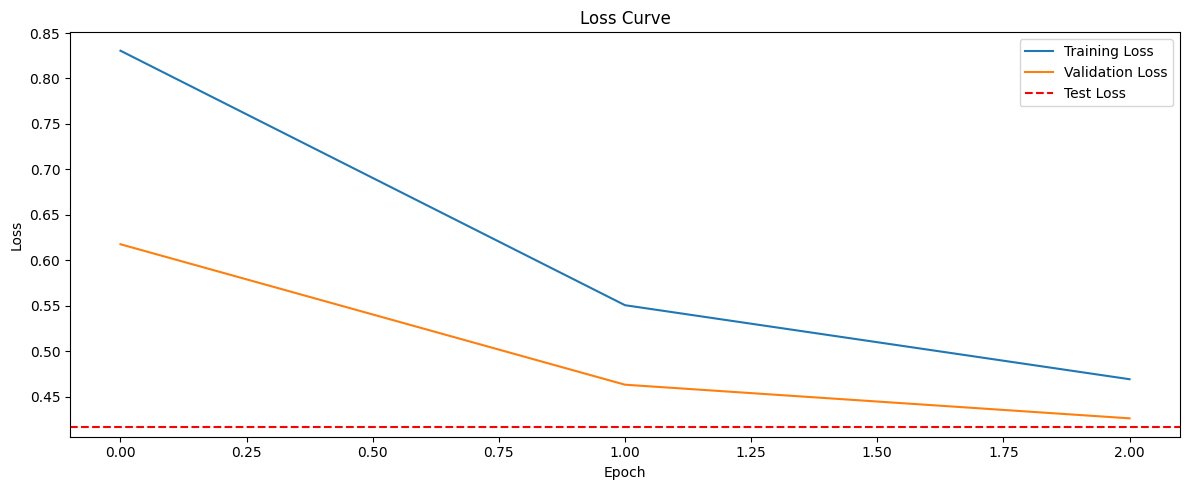

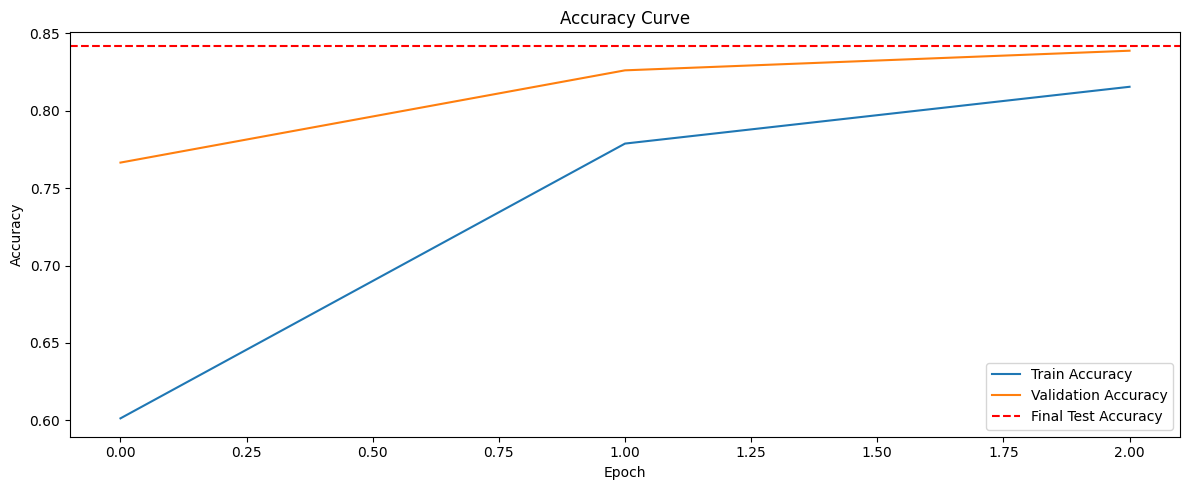

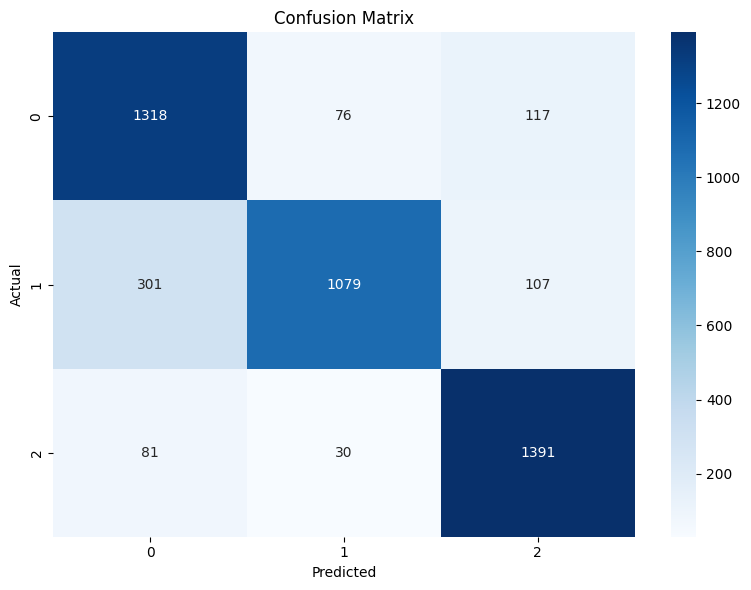

In [ ]:
with open("model_1_values.pkl", "rb") as f:
    loaded_data = pickle.load(f)

labels_test_total = loaded_data["labels_test_total"]
test_predictions = loaded_data["test_predictions"]
test_probabilities = loaded_data["test_probabilities"]
test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(labels_test_total, test_predictions, test_probabilities.cpu(), test_loss, train_losses,  train_accuracies, validation_losses,validation_accuracies)

<h4> Model 2: RMSprop optimizer with batch size 32

Accuracy: 0.8293

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.86      0.79      1479
           1       0.86      0.74      0.80      1509
           2       0.92      0.89      0.91      1512

    accuracy                           0.83      4500
   macro avg       0.84      0.83      0.83      4500
weighted avg       0.84      0.83      0.83      4500



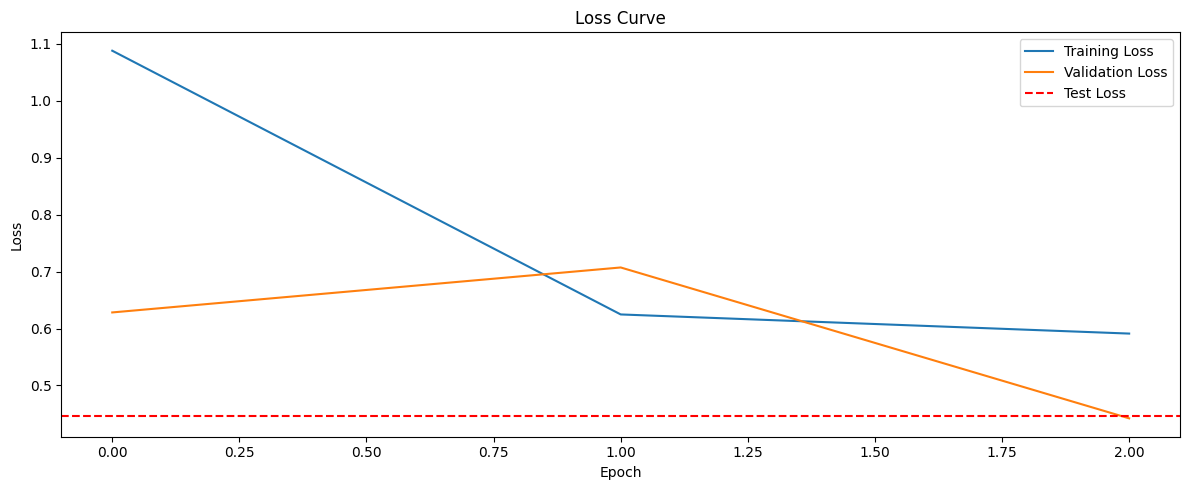

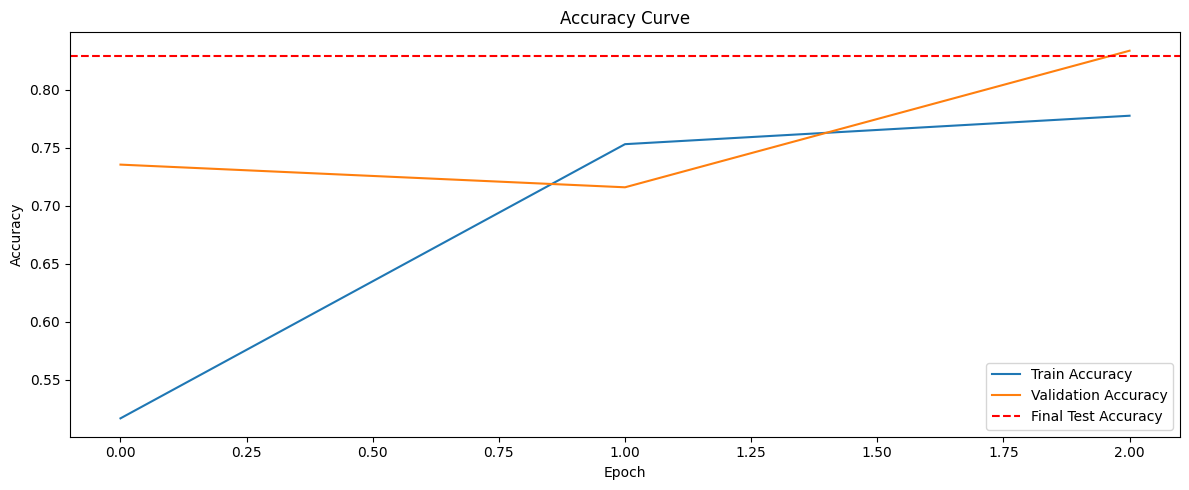

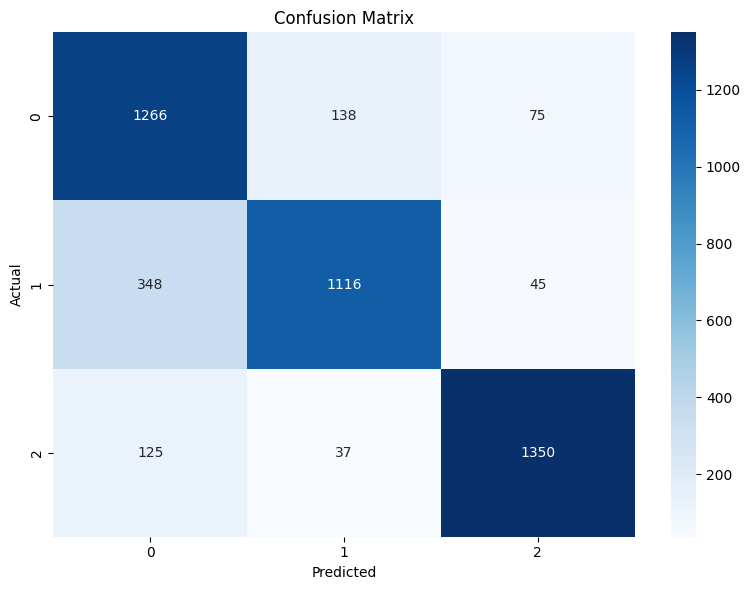

In [ ]:
with open("model_2_values.pkl", "rb") as f:
    loaded_data = pickle.load(f)

labels_test_total = loaded_data["labels_test_total"]
test_predictions = loaded_data["test_predictions"]
test_probabilities = loaded_data["test_probabilities"]
test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(labels_test_total, test_predictions, test_probabilities.cpu(), test_loss, train_losses, train_accuracies, validation_losses, validation_accuracies)

<h4> Model 3: AdamW optimizer with batch size 32

Accuracy: 0.6758

Classification Report:
               precision    recall  f1-score   support

           0       0.57      0.90      0.70      1547
           1       0.73      0.75      0.74      1451
           2       0.99      0.38      0.55      1502

    accuracy                           0.68      4500
   macro avg       0.76      0.67      0.66      4500
weighted avg       0.76      0.68      0.66      4500



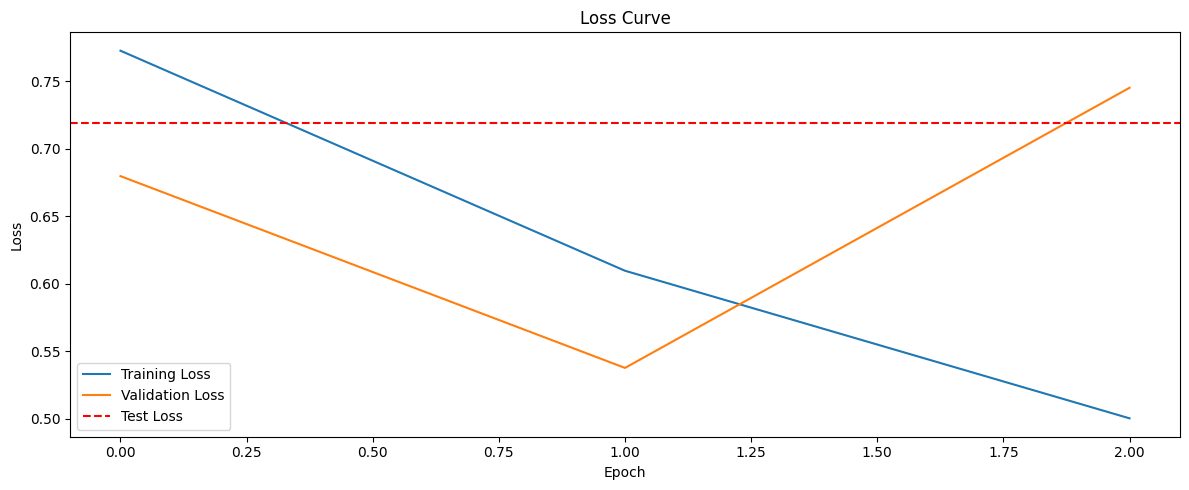

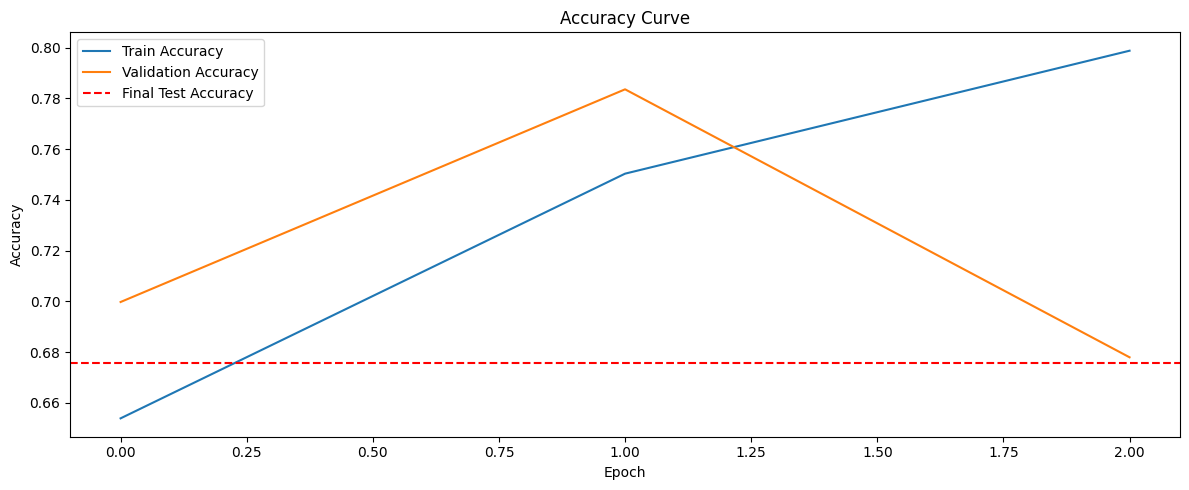

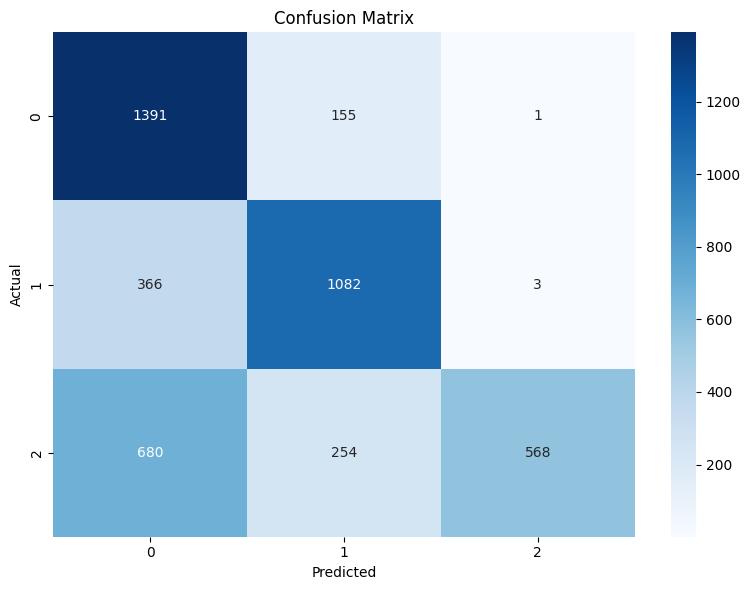

In [ ]:
with open("model_3_values.pkl", "rb") as f:
    loaded_data = pickle.load(f)

labels_test_total = loaded_data["labels_test_total"]
test_predictions = loaded_data["test_predictions"]
test_probabilities = loaded_data["test_probabilities"]
test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(labels_test_total, test_predictions, test_probabilities.cpu(), test_loss, train_losses, train_accuracies, validation_losses, validation_accuracies)

<h4> Model 4: Adam optimizer with batch size 64

Accuracy: 0.8533

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.81      0.82      1494
           1       0.81      0.86      0.84      1481
           2       0.92      0.89      0.91      1525

    accuracy                           0.85      4500
   macro avg       0.85      0.85      0.85      4500
weighted avg       0.85      0.85      0.85      4500



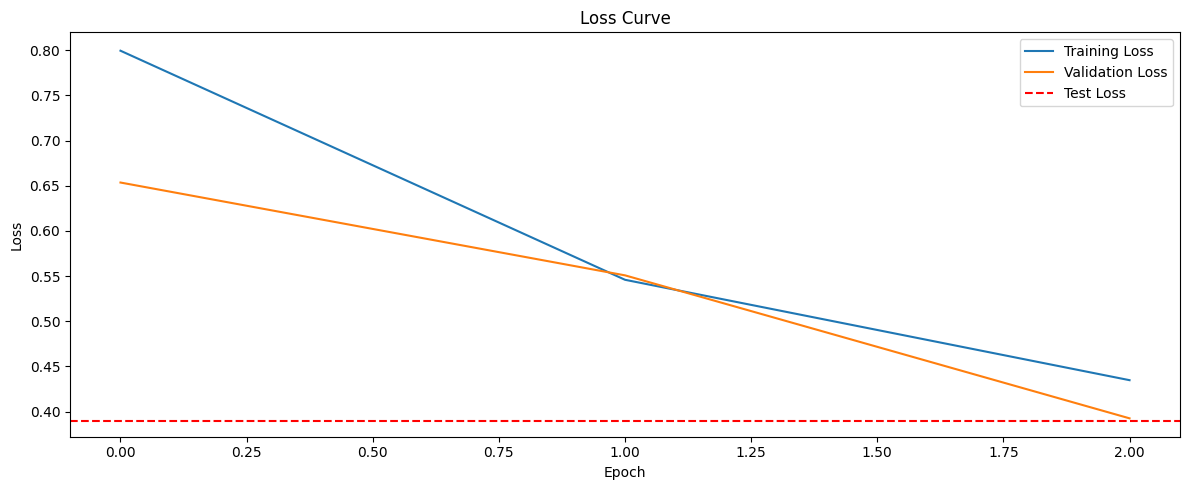

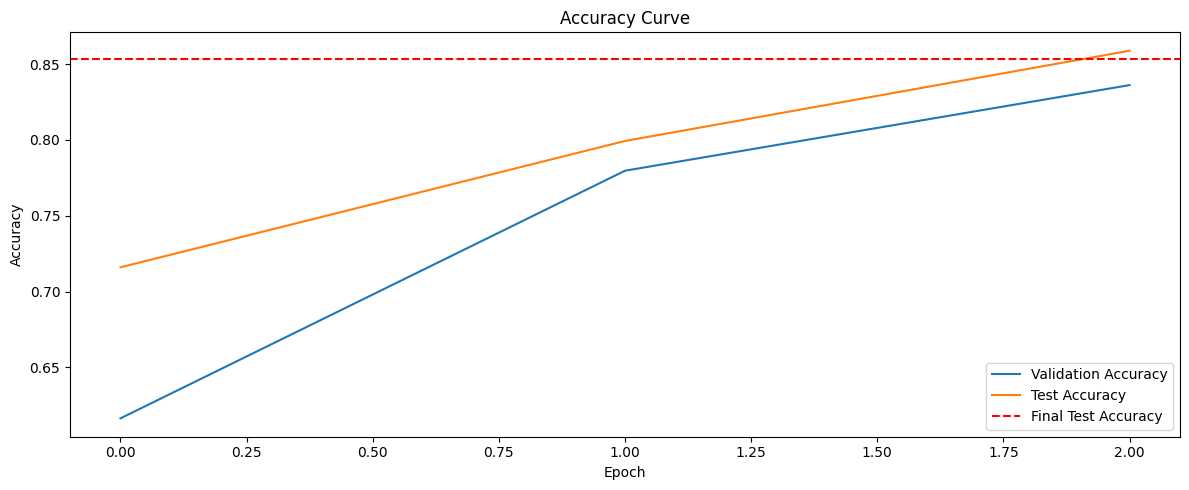

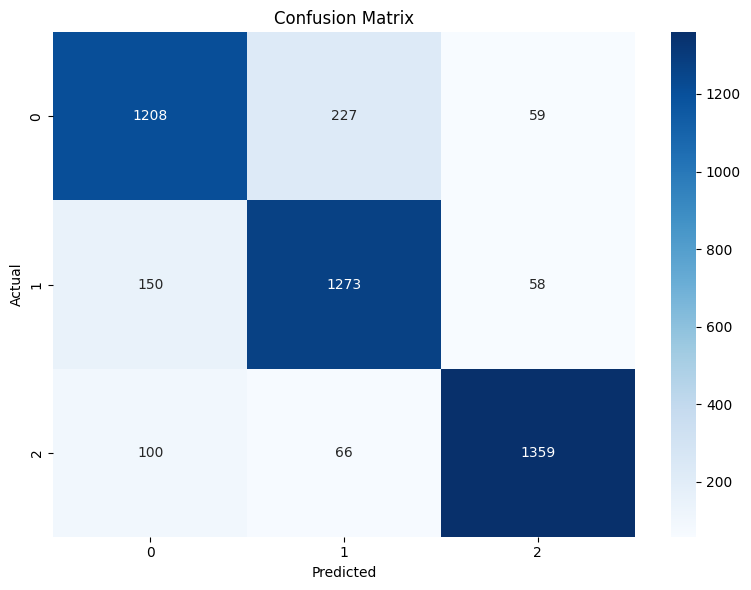

In [ ]:
with open("model_4_values.pkl", "rb") as f:
    loaded_data = pickle.load(f)

labels_test_total = loaded_data["labels_test_total"]
test_predictions = loaded_data["test_predictions"]
test_probabilities = loaded_data["test_probabilities"]
test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(labels_test_total, test_predictions, test_probabilities.cpu(), test_loss, train_losses, train_accuracies, validation_losses, validation_accuracies)

<h4> Model 5: Adam optimizer with batch size 64 & LeCun Weight Init

Accuracy: 0.8356

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.92      0.81      1460
           1       0.89      0.72      0.80      1542
           2       0.93      0.88      0.90      1498

    accuracy                           0.84      4500
   macro avg       0.85      0.84      0.84      4500
weighted avg       0.85      0.84      0.84      4500



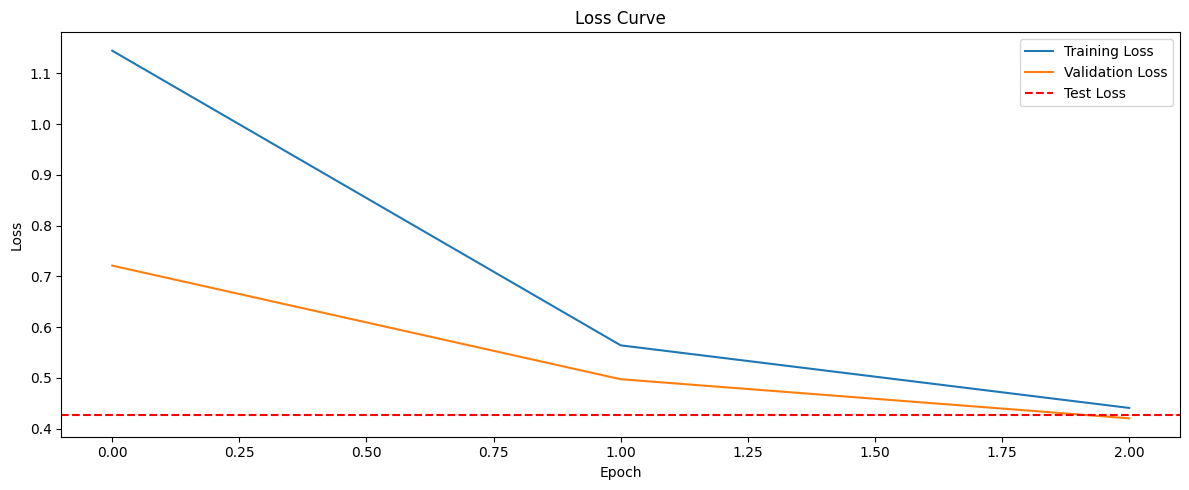

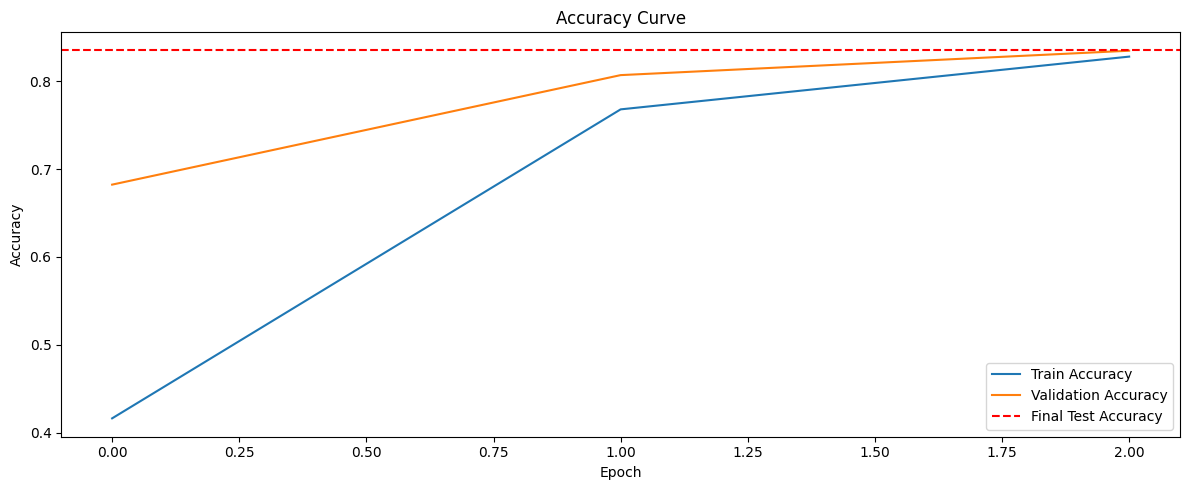

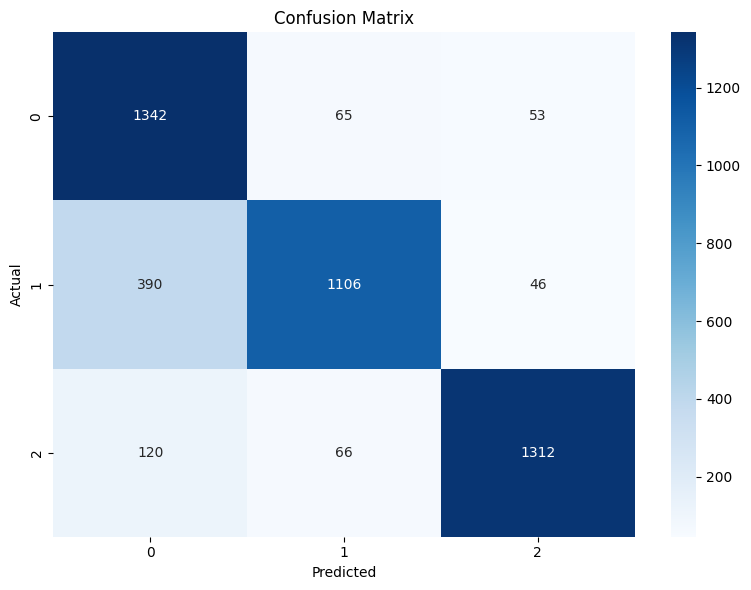

In [ ]:
with open("model_5_values.pkl", "rb") as f:
    loaded_data = pickle.load(f)

labels_test_total = loaded_data["labels_test_total"]
test_predictions = loaded_data["test_predictions"]
test_probabilities = loaded_data["test_probabilities"]
test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(labels_test_total, test_predictions, test_probabilities.cpu(), test_loss, train_losses, train_accuracies, validation_losses, validation_accuracies)

<h4> Model 6: Adam optimizer with batch size 64 & He Weight Init

Accuracy: 0.8702

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.85      0.85      1535
           1       0.84      0.87      0.85      1453
           2       0.94      0.89      0.91      1512

    accuracy                           0.87      4500
   macro avg       0.87      0.87      0.87      4500
weighted avg       0.87      0.87      0.87      4500



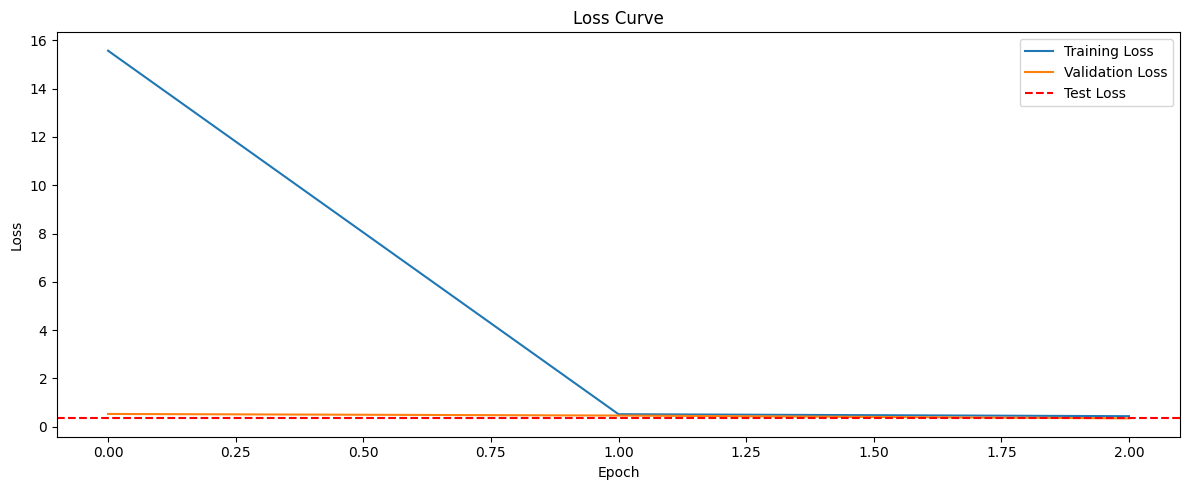

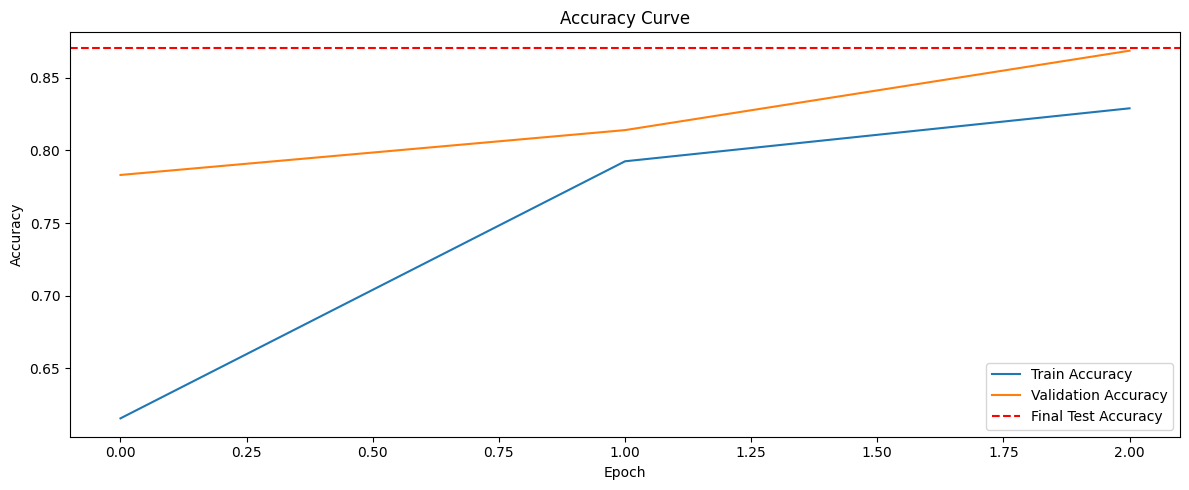

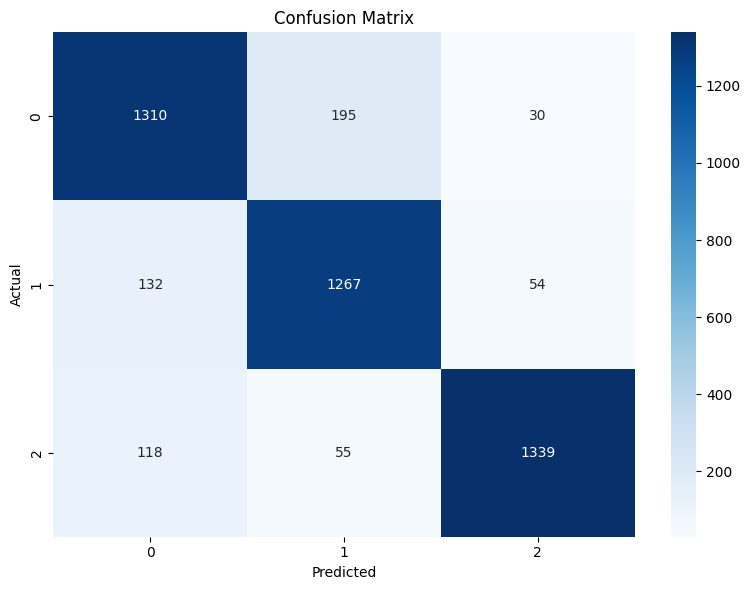

In [ ]:
with open("model_6_values.pkl", "rb") as f:
    loaded_data = pickle.load(f)

labels_test_total = loaded_data["labels_test_total"]
test_predictions = loaded_data["test_predictions"]
test_probabilities = loaded_data["test_probabilities"]
test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(labels_test_total, test_predictions, test_probabilities.cpu(), test_loss, train_losses, train_accuracies, validation_losses, validation_accuracies)

<h4> Model 7: Adam optimizer with batch size 64, He Weight Init & Regularization enabled

Accuracy: 0.8764

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.86      0.88      1483
           1       0.78      0.96      0.86      1519
           2       0.98      0.81      0.89      1498

    accuracy                           0.88      4500
   macro avg       0.89      0.88      0.88      4500
weighted avg       0.89      0.88      0.88      4500



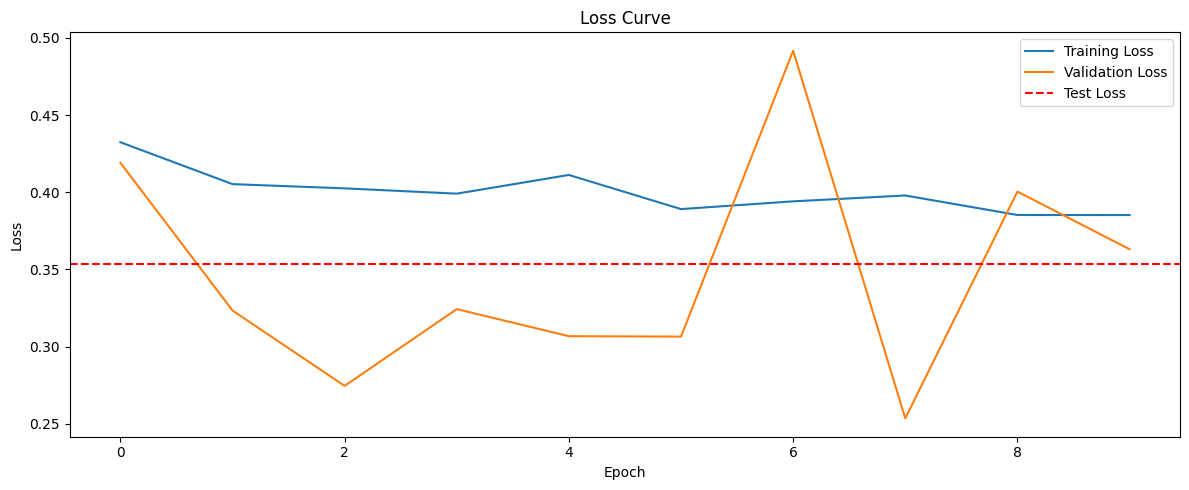

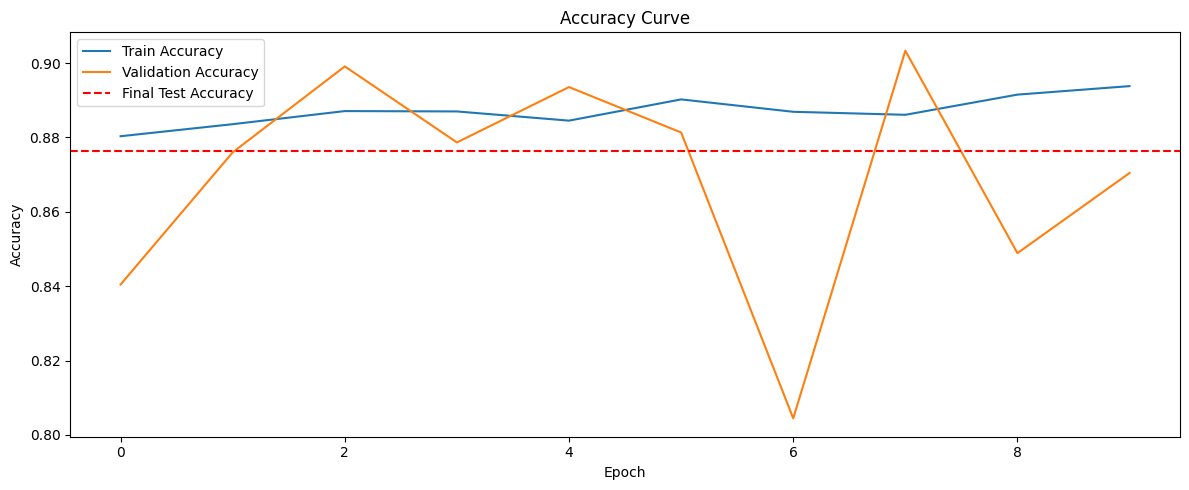

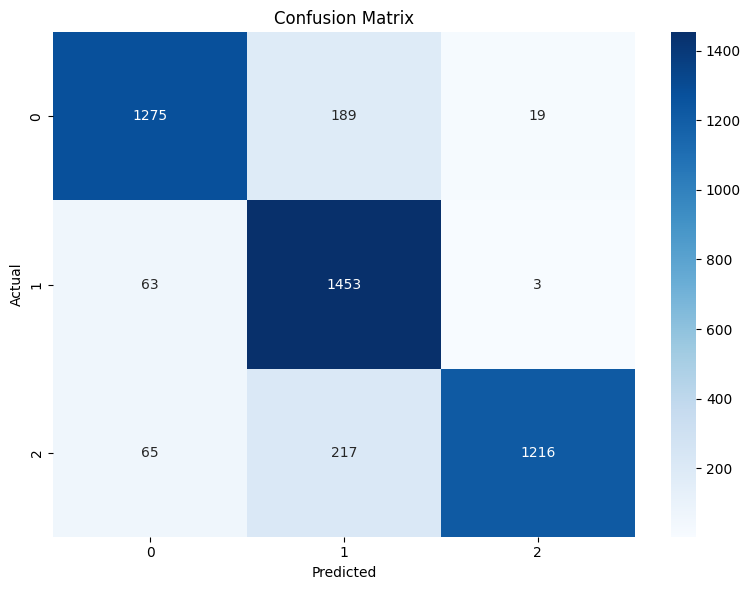

In [ ]:
with open("model_7_values_3.pkl", "rb") as f:
    loaded_data = pickle.load(f)

labels_test_total = loaded_data["labels_test_total"]
test_predictions = loaded_data["test_predictions"]
test_probabilities = loaded_data["test_probabilities"]
test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(labels_test_total, test_predictions, test_probabilities.cpu(), test_loss, train_losses, train_accuracies, validation_losses, validation_accuracies)

<h4> Comparison of All models in a single plot

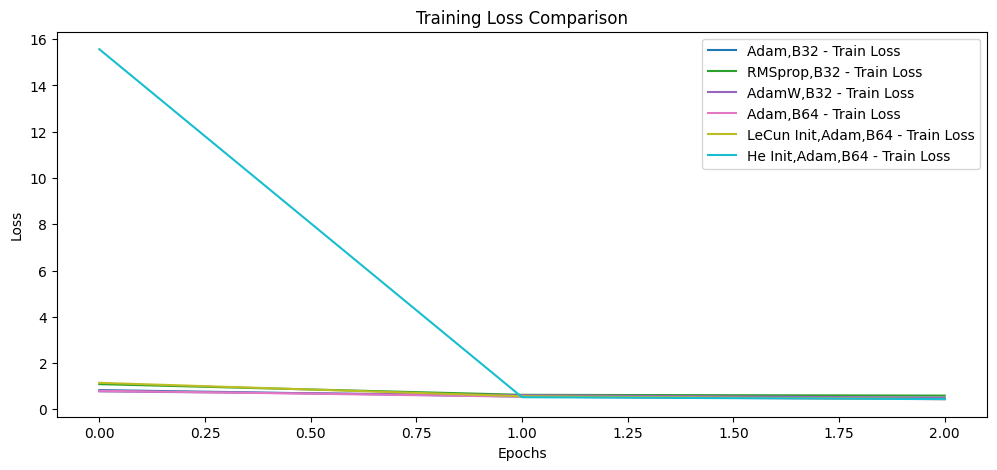

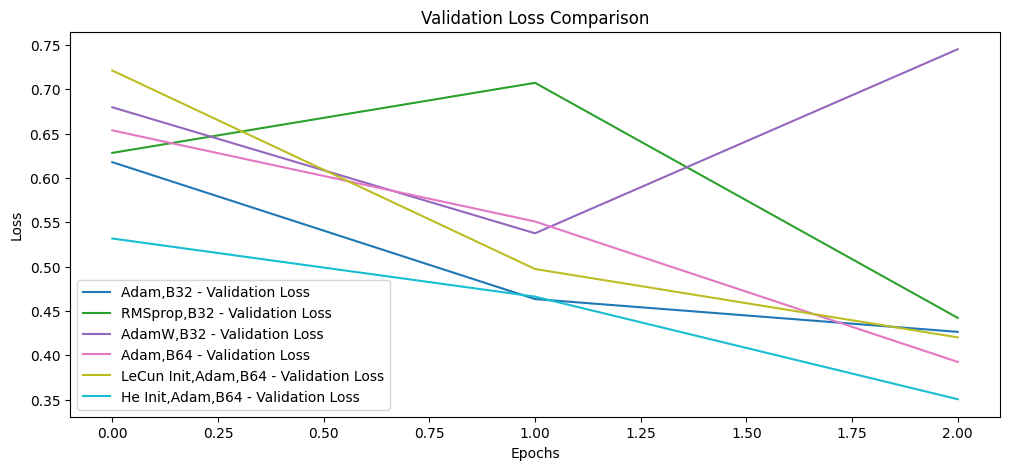

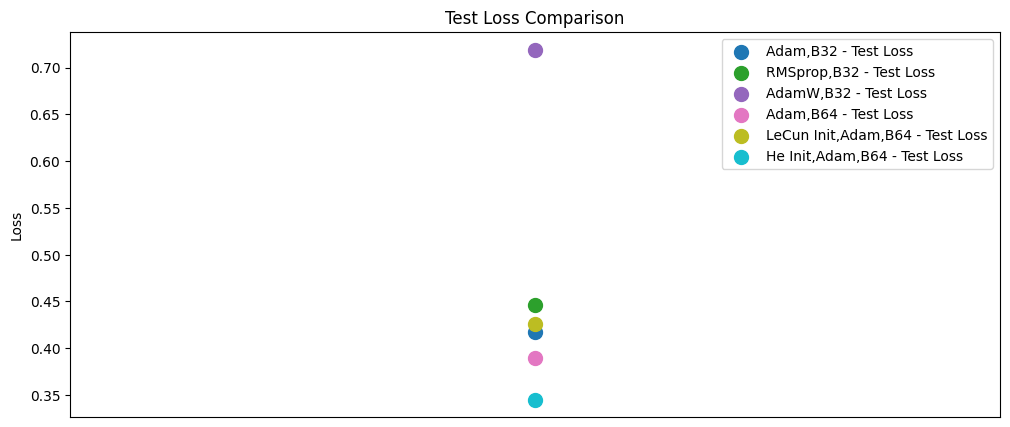

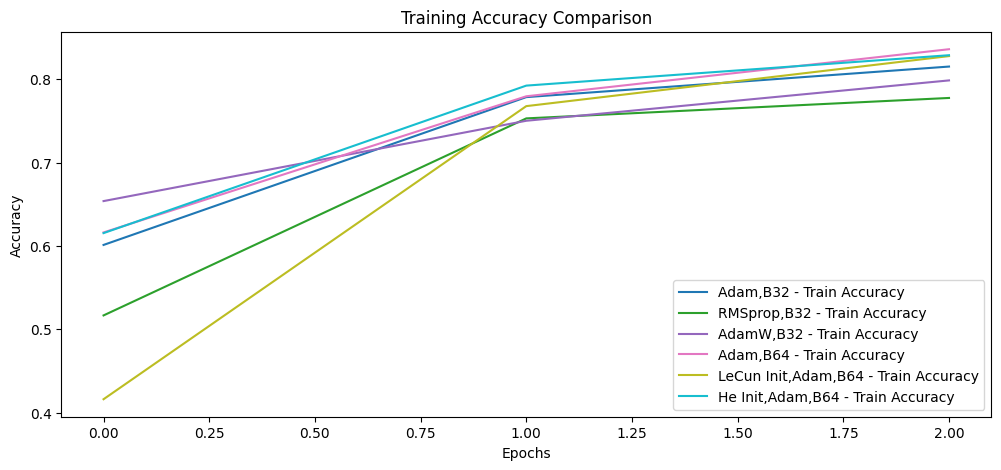

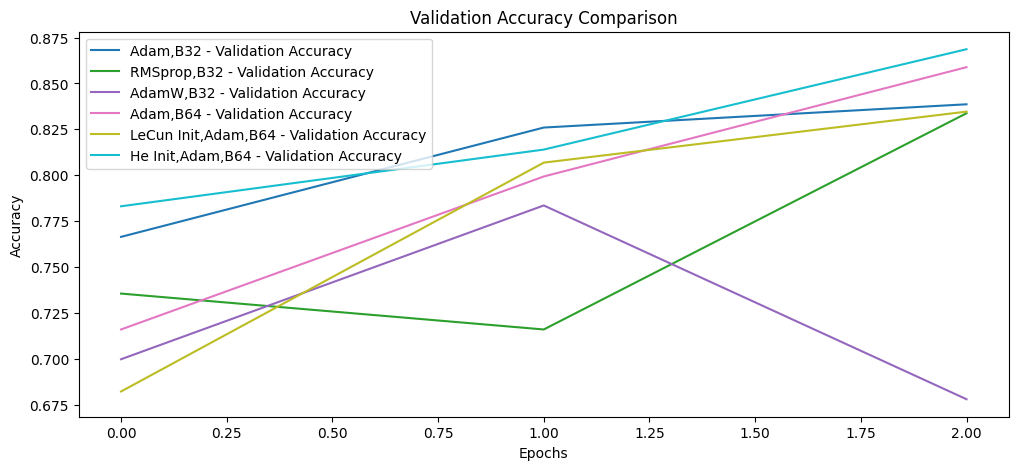

In [ ]:
model_name_map = {
    "model_1_values.pkl": "Adam,B32",
    "model_2_values.pkl": "RMSprop,B32",
    "model_3_values.pkl": "AdamW,B32",
    "model_4_values.pkl": "Adam,B64",
    "model_5_values.pkl": "LeCun Init,Adam,B64",
    "model_6_values.pkl": "He Init,Adam,B64"
}

models_data = {}
for model_file, model_label in model_name_map.items():
    with open(model_file, "rb") as f:
        models_data[model_label] = pickle.load(f)

colors = plt.cm.tab10(np.linspace(0, 1, len(models_data)))

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.plot(data["train_losses"], label=f"{model_label} - Train Loss", color=color)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.plot(data["validation_losses"], label=f"{model_label} - Validation Loss", color=color)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.scatter([1], [data["test_loss"]], label=f"{model_label} - Test Loss", color=color, s=100, marker='o')
plt.xticks([])
plt.ylabel("Loss")
plt.title("Test Loss Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.plot(data["train_accuracies"], label=f"{model_label} - Train Accuracy", color=color)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.plot(data["validation_accuracies"], label=f"{model_label} - Validation Accuracy", color=color)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()


<h4>Misclassified images of best VGG Model

Misclassified images of Enhanced VGG model:


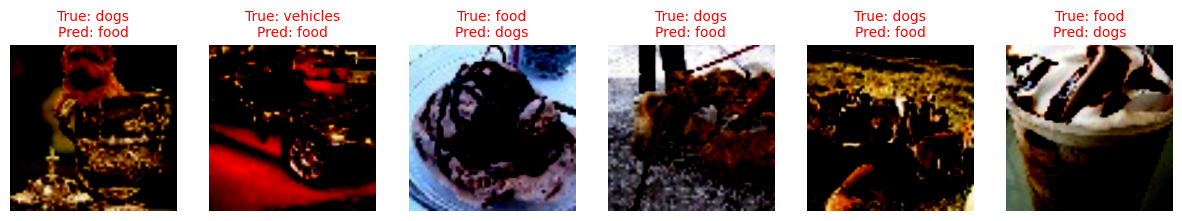

In [20]:
class_names = ['dogs', 'food', 'vehicles']

model = VGG13_C()
model.load_state_dict(torch.load("model_7.pth", weights_only=True, map_location=torch.device('cpu')))
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

data_dir = "cnn_dataset"
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

def get_dataloader(dataset, batch_size=32):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

dataloaders = {
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

print("Misclassified images of Enhanced VGG model:")

display_misclassified_images(model, dataloaders["test_64"], device, class_names, num_images=6)


Misclassified images are of low quality, improper lighting and does not have viable information to predict.

6. Save the weights of the trained network.

In [ ]:
torch.save(model_7.state_dict(), "/user/dshrisai/best_model.pth")

## Step 3: Implementing ResNet

1. Implement residual blocks of ResNet.

In [21]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels * self.expansion)
        self.downsample = downsample

    def forward(self, x):
        identity = x

        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        return F.relu(out)

2. Assemble the ResNet-18 architecture.

In [ ]:
class ResNet(nn.Module):
    def __init__(self, block, layers, num_classes=3):
        super(ResNet, self).__init__()
        self.in_channels = 64

        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        self.layer1 = self._make_layer(block, 64, layers[0], stride=1)
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2)
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2)
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        self._initialize_weights()

    def _make_layer(self, block, out_channels, num_blocks, stride):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion)
            )

        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion

        for _ in range(1, num_blocks):
            layers.append(block(self.in_channels, out_channels))

        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def resnet18(num_classes=3):
    return ResNet(BasicBlock, [2, 2, 2, 2], num_classes=num_classes).to(device)

print(resnet18())

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), pad

3. Train the ResNet-18 model.

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

data_dir = "/content/cnn_dataset"
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

def get_dataloader(dataset, batch_size=32):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

dataloaders = {
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:617: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


In [ ]:
model_resnet_1 = resnet18()

optimizer_resnet_1 = torch.optim.Adam(model_resnet_1.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses_resnet_base, train_accuracies_resnet_base, validation_losses_resnet_base, validation_accuracies_resnet_base = train_and_validate(
    model=model_resnet_1,
    train_loader=dataloaders['train_64'],
    val_loader=dataloaders['val_64'],
    device=device,
    optimizer=optimizer_resnet_1,
    criterion=criterion,
    num_epochs=10,
    l2_scheduler=False
)

Epoch 1/10 - Time: 74.22 sec
Training Loss: 0.4747, Training Accuracy: 0.8158
Validation Loss: 0.3912,Validation Accuracy: 0.8620
Epoch 2/10 - Time: 71.07 sec
Training Loss: 0.3347, Training Accuracy: 0.8751
Validation Loss: 0.3986,Validation Accuracy: 0.8387
Epoch 3/10 - Time: 72.14 sec
Training Loss: 0.2820, Training Accuracy: 0.8953
Validation Loss: 0.2973,Validation Accuracy: 0.8958
Epoch 4/10 - Time: 71.52 sec
Training Loss: 0.2422, Training Accuracy: 0.9115
Validation Loss: 0.2126,Validation Accuracy: 0.9231
Epoch 5/10 - Time: 73.42 sec
Training Loss: 0.2131, Training Accuracy: 0.9212
Validation Loss: 0.2497,Validation Accuracy: 0.9040
Epoch 6/10 - Time: 72.98 sec
Training Loss: 0.1869, Training Accuracy: 0.9310
Validation Loss: 0.4557,Validation Accuracy: 0.8744
Epoch 7/10 - Time: 72.44 sec
Training Loss: 0.1757, Training Accuracy: 0.9325
Validation Loss: 0.1977,Validation Accuracy: 0.9240
Epoch 8/10 - Time: 72.32 sec
Training Loss: 0.1540, Training Accuracy: 0.9432
Validation L

In [ ]:
torch.save(model_resnet_1.state_dict(), "/content/drive/MyDrive/model_resnet_base.pth")
print("Resnet Base Model saved successfully!")

Resnet Base Model saved successfully!


In [ ]:
model_resnet_1.load_state_dict(torch.load("/content/drive/MyDrive/model_resnet_base.pth", weights_only=True))
labels_test_total_resnet_base, test_predictions_resnet_base, test_probabilities_resnet_base, test_loss_resnet_base, test_accuracy_resnet_base = test_model(model_resnet_1,dataloaders['test_64'],device,criterion)

Test Accuracy: 91.64%
Test Loss: 0.2177


In [ ]:
model_resnet_base_values = {
    "labels_test_total": labels_test_total_resnet_base,
    "test_predictions": test_predictions_resnet_base,
    "test_probabilities": test_probabilities_resnet_base.cpu(),
    "test_loss": test_loss_resnet_base,
    "train_losses": train_losses_resnet_base,
    "train_accuracies": train_accuracies_resnet_base,
    "validation_losses": validation_losses_resnet_base,
    "validation_accuracies": validation_accuracies_resnet_base
}

with open("/content/drive/MyDrive/model_resnet_base_values.pkl", "wb") as f:
    pickle.dump(model_resnet_base_values, f)
print("Variables saved successfully!")

Variables saved successfully!


4. Apply regularization techniques.

In [ ]:
transform2 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

data_dir = "/content/cnn_dataset"
dataset = datasets.ImageFolder(root=data_dir, transform=transform2)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

def get_dataloader(dataset, batch_size=32):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

dataloaders = {
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

In [ ]:
model_resnet_2 = resnet18()
model_resnet_2.load_state_dict(torch.load("/content/drive/MyDrive/model_resnet_enn.pth", weights_only=True))

optimizer_resnet = torch.optim.Adam(model_resnet_2.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

train_losses_resnet_enn, train_accuracies_resnet_enn, validation_losses_resnet_enn, validation_accuracies_resnet_enn = train_and_validate(
    model=model_resnet_2,
    train_loader=dataloaders['train_64'],
    val_loader=dataloaders['val_64'],
    device=device,
    optimizer=optimizer_resnet,
    criterion=criterion,
    num_epochs=10,
    l2_scheduler=True,
    early_stopping=5
)

torch.save(model_resnet_2.state_dict(), "/content/drive/MyDrive/model_resnet_enn.pth")
print("Resnet Enhanced Model saved successfully!")

Epoch 1/10 - Time: 172.56 sec
Training Loss: 0.3281, Training Accuracy: 0.9132
Validation Loss: 0.2334,Validation Accuracy: 0.9158
Epoch 2/10 - Time: 180.68 sec
Training Loss: 0.3171, Training Accuracy: 0.9162
Validation Loss: 0.2368,Validation Accuracy: 0.9178
Epoch 3/10 - Time: 174.40 sec
Training Loss: 0.3190, Training Accuracy: 0.9144
Validation Loss: 0.2425,Validation Accuracy: 0.9093
Epoch 4/10 - Time: 175.51 sec
Training Loss: 0.3144, Training Accuracy: 0.9163
Validation Loss: 0.2626,Validation Accuracy: 0.8989
Epoch 5/10 - Time: 173.30 sec
Training Loss: 0.3211, Training Accuracy: 0.9159
Validation Loss: 0.5926,Validation Accuracy: 0.7933
Epoch 6/10 - Time: 176.74 sec
Training Loss: 0.3098, Training Accuracy: 0.9176
Validation Loss: 0.1989,Validation Accuracy: 0.9320
Epoch 7/10 - Time: 175.58 sec
Training Loss: 0.3011, Training Accuracy: 0.9204
Validation Loss: 0.2648,Validation Accuracy: 0.8942
Epoch 8/10 - Time: 174.22 sec
Training Loss: 0.3082, Training Accuracy: 0.9179
Vali

In [ ]:
model_resnet_2.load_state_dict(torch.load("/content/drive/MyDrive/model_resnet_enn.pth", weights_only=True))
labels_test_total_resnet_enn, test_predictions_resnet_enn, test_probabilities_resnet_enn, test_loss_resnet_enn, test_accuracy_resnet_enn = test_model(model_resnet_2,dataloaders['test_64'],device,criterion)

Test Accuracy: 91.78%
Test Loss: 0.2278


In [ ]:
model_resnet_enn_values = {
    "labels_test_total": labels_test_total_resnet_enn,
    "test_predictions": test_predictions_resnet_enn,
    "test_probabilities": test_probabilities_resnet_enn.cpu(),
    "test_loss": test_loss_resnet_enn,
    "train_losses": train_losses_resnet_enn,
    "train_accuracies": train_accuracies_resnet_enn,
    "validation_losses": validation_losses_resnet_enn,
    "validation_accuracies": validation_accuracies_resnet_enn
}

with open("/content/drive/MyDrive/model_resnet_enn_values_2.pkl", "wb") as f:
    pickle.dump(model_resnet_enn_values, f)
print("Variables saved successfully!")

Variables saved successfully!


5. Evaluation and analysis.

<h4> Base Resnet18 Model with Adam optimizer, batch size 64 & LeCun Weight Init

Accuracy: 0.9164

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90      1542
           1       0.95      0.83      0.89      1457
           2       0.95      0.96      0.96      1501

    accuracy                           0.92      4500
   macro avg       0.92      0.92      0.92      4500
weighted avg       0.92      0.92      0.92      4500



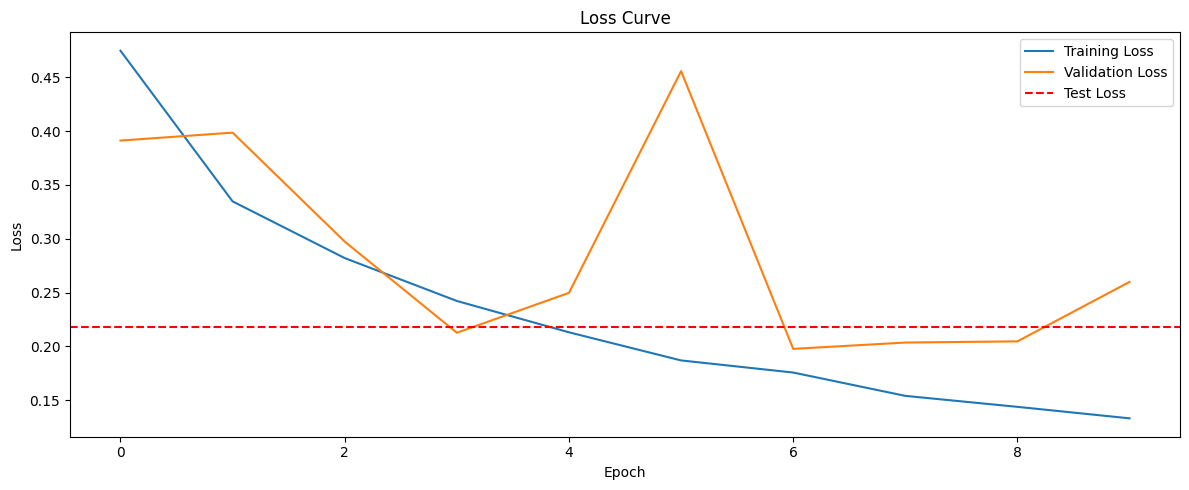

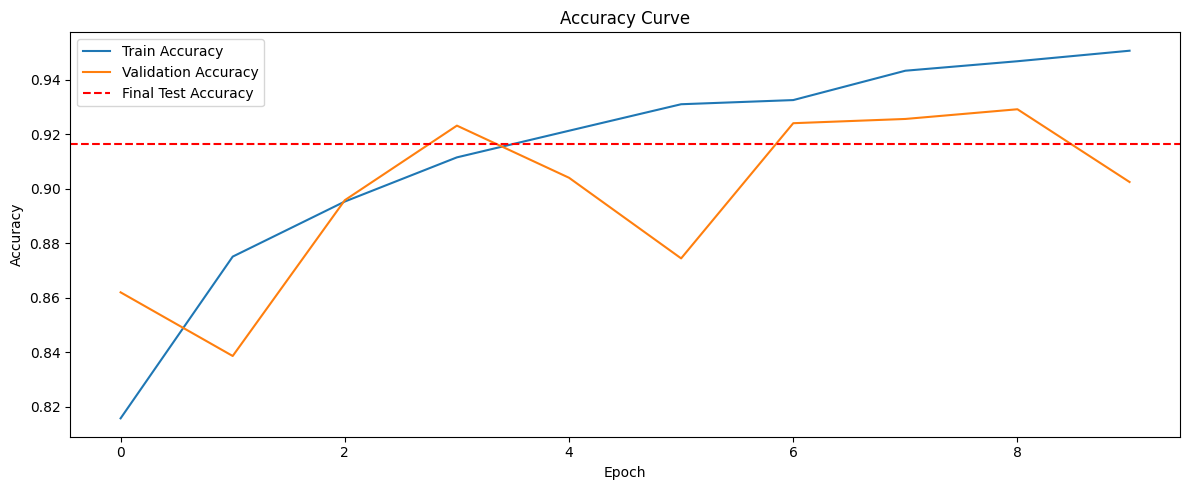

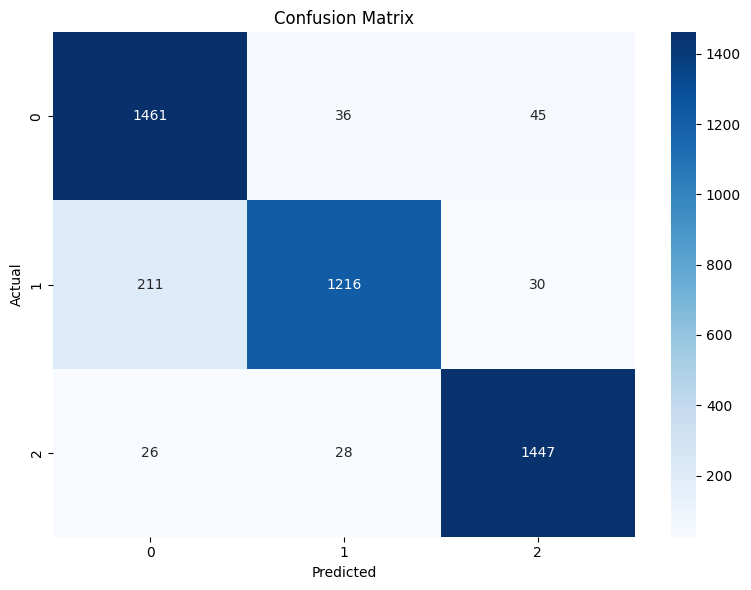

In [6]:
with open("/content/drive/MyDrive/model_resnet_base_values.pkl", "rb") as f:
    loaded_data = pickle.load(f)

labels_test_total = loaded_data["labels_test_total"]
test_predictions = loaded_data["test_predictions"]
test_probabilities = loaded_data["test_probabilities"]
test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(labels_test_total, test_predictions, test_probabilities.cpu(), test_loss, train_losses, train_accuracies, validation_losses, validation_accuracies)

<h4> Enhanced Resnet18 Model with Adam optimizer, batch size 64, LeCun Weight Init & regularization enabled

Accuracy: 0.9178

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.88      0.91      1487
           1       0.91      0.91      0.91      1533
           2       0.91      0.96      0.94      1480

    accuracy                           0.92      4500
   macro avg       0.92      0.92      0.92      4500
weighted avg       0.92      0.92      0.92      4500



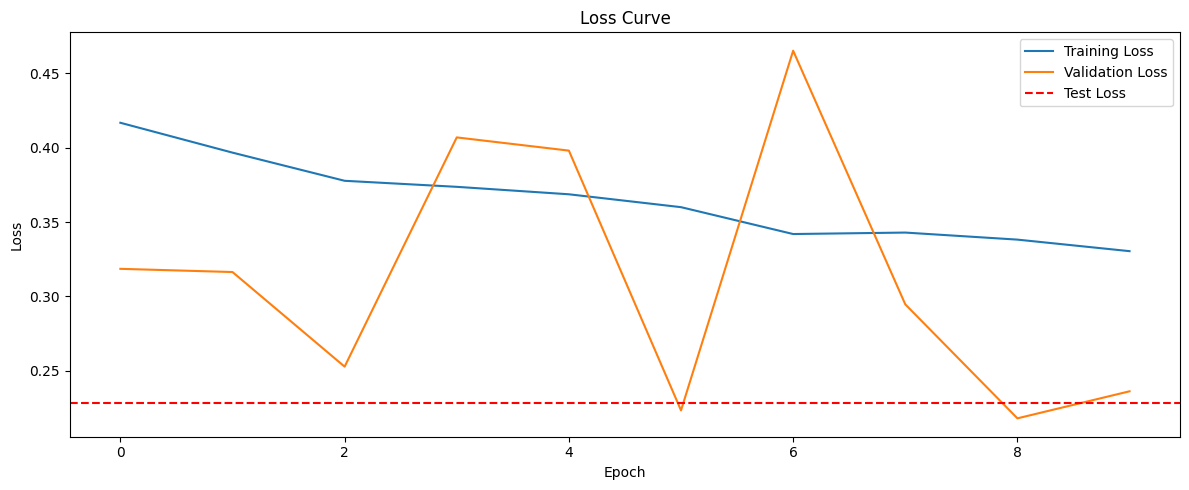

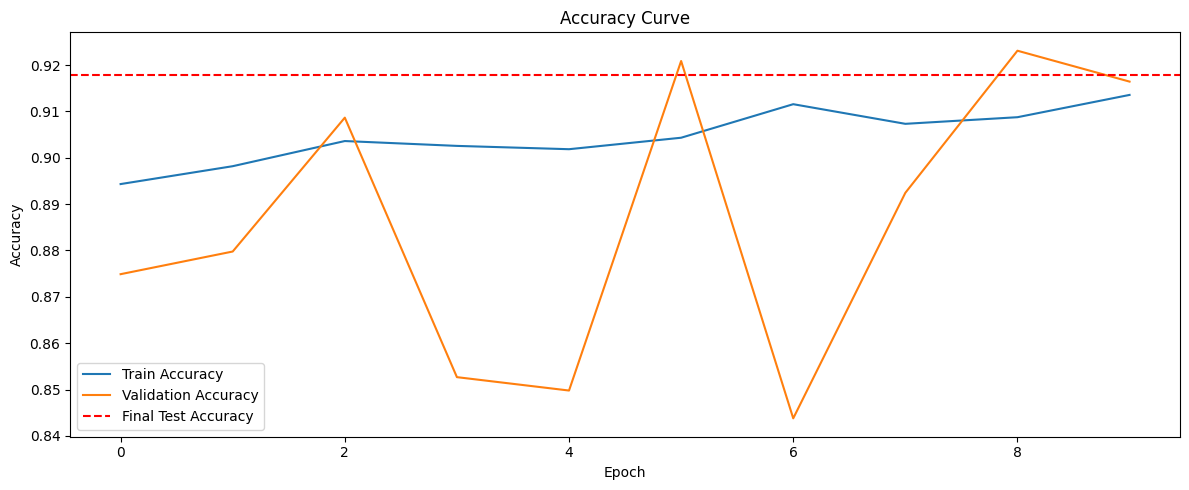

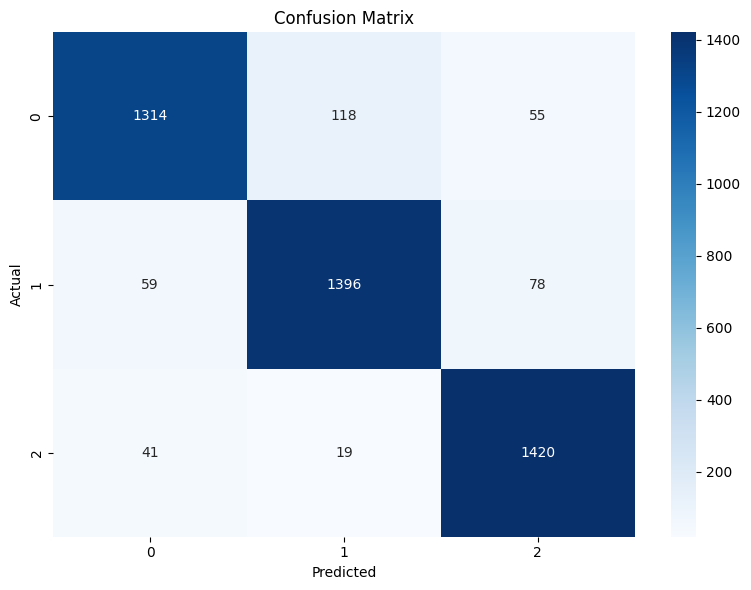

In [7]:
with open("/content/drive/MyDrive/model_resnet_enn_values_2.pkl", "rb") as f:
    loaded_data = pickle.load(f)

labels_test_total = loaded_data["labels_test_total"]
test_predictions = loaded_data["test_predictions"]
test_probabilities = loaded_data["test_probabilities"]
test_loss = loaded_data["test_loss"]
train_losses = loaded_data["train_losses"]
train_accuracies = loaded_data["train_accuracies"]
validation_losses = loaded_data["validation_losses"]
validation_accuracies = loaded_data["validation_accuracies"]

metrics(labels_test_total, test_predictions, test_probabilities.cpu(), test_loss, train_losses, train_accuracies, validation_losses, validation_accuracies)

<h4> Comparison between the best VGG and Resnet model

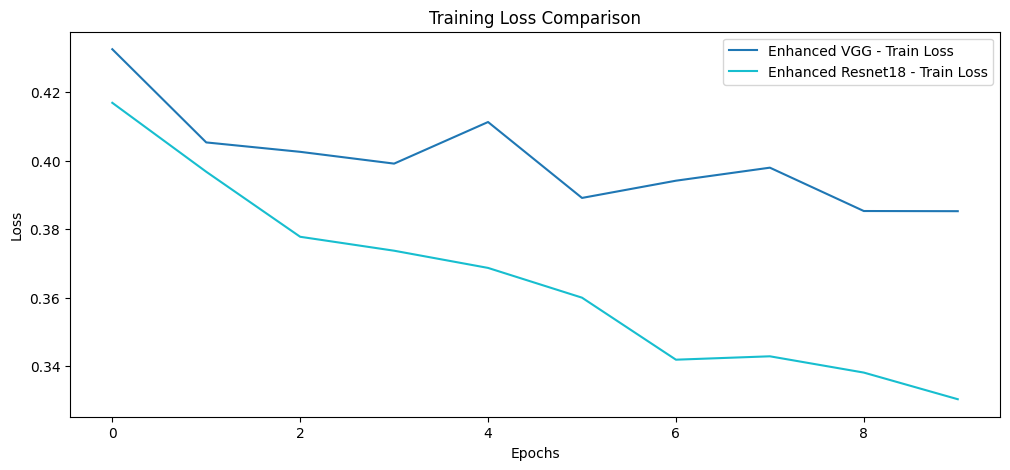

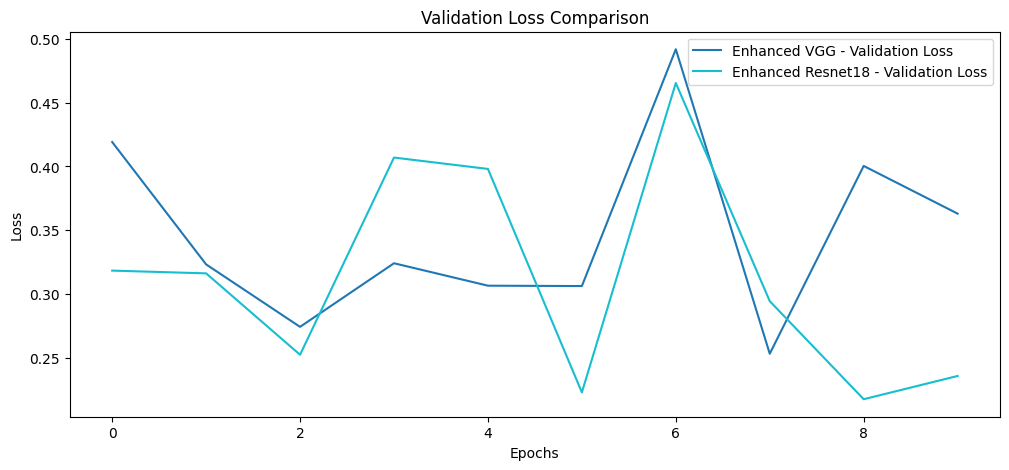

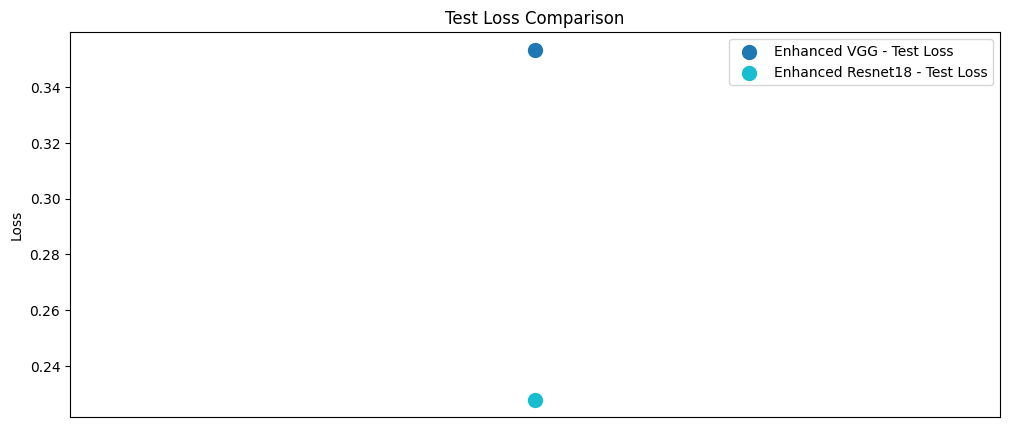

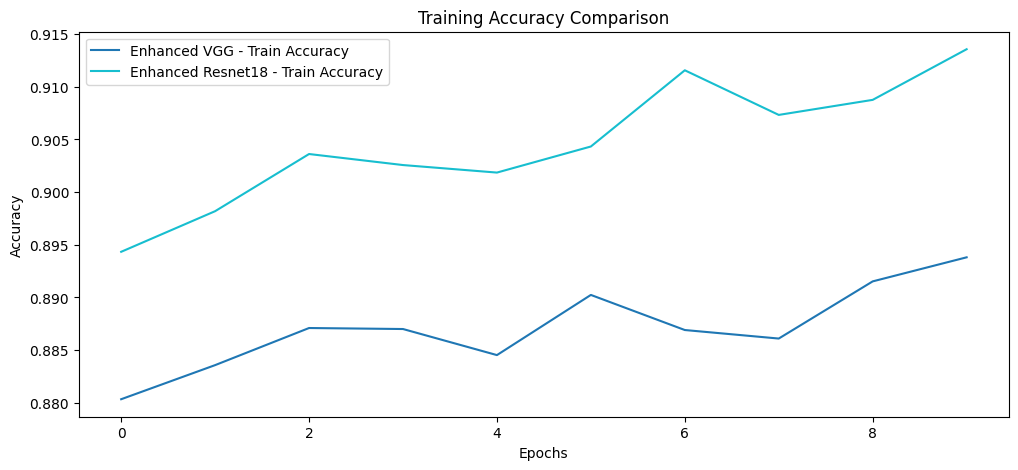

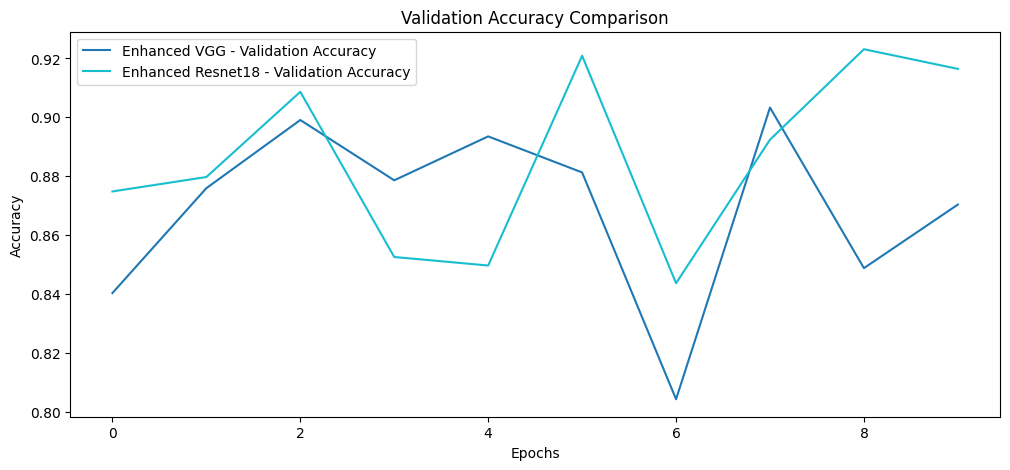

In [8]:
model_name_map = {
    "model_7_values_3.pkl": "Enhanced VGG",
    "/content/drive/MyDrive/model_resnet_enn_values_2.pkl": "Enhanced Resnet18"
}

models_data = {}
for model_file, model_label in model_name_map.items():
    with open(model_file, "rb") as f:
        models_data[model_label] = pickle.load(f)

colors = plt.cm.tab10(np.linspace(0, 1, len(models_data)))

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.plot(data["train_losses"], label=f"{model_label} - Train Loss", color=color)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.plot(data["validation_losses"], label=f"{model_label} - Validation Loss", color=color)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.scatter([1], [data["test_loss"]], label=f"{model_label} - Test Loss", color=color, s=100, marker='o')
plt.xticks([])
plt.ylabel("Loss")
plt.title("Test Loss Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.plot(data["train_accuracies"], label=f"{model_label} - Train Accuracy", color=color)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training Accuracy Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
for (model_label, data), color in zip(models_data.items(), colors):
    plt.plot(data["validation_accuracies"], label=f"{model_label} - Validation Accuracy", color=color)
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()


<h4> Misclassified images of best Resnet18 model

Misclassified images of Enhanced Resnet model:


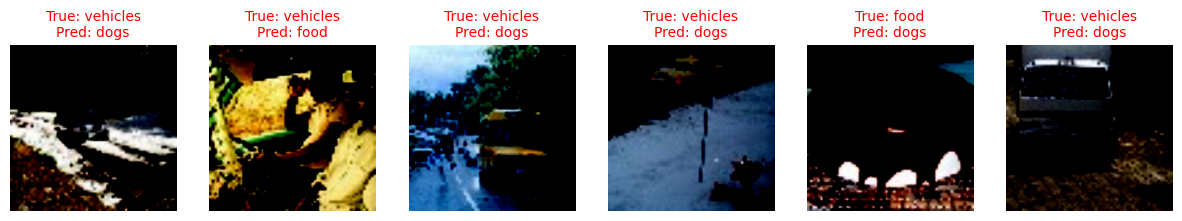

In [27]:
class_names = ['dogs', 'food', 'vehicles']

model = resnet18()
model.load_state_dict(torch.load("/content/drive/MyDrive/model_resnet_enn.pth", weights_only=True, map_location=torch.device('cpu')))
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

data_dir = "cnn_dataset"
dataset = datasets.ImageFolder(root=data_dir, transform=transform)
train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])

def get_dataloader(dataset, batch_size=32):
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

dataloaders = {
    'train_64': get_dataloader(train_dataset, batch_size=64),
    'val_64': get_dataloader(val_dataset, batch_size=64),
    'test_64': get_dataloader(test_dataset, batch_size=64)
}

print("Misclassified images of Enhanced Resnet model:")

display_misclassified_images(model, dataloaders["test_64"], device, class_names, num_images=6)


Misclassified images are of low quality, improper lighting and does not have viable information to predict.

6. Save the weights of the trained network.

In [ ]:
model_resnet_2.load_state_dict(torch.load("/content/drive/MyDrive/model_resnet_enn_best.pth", weights_only=True))

## Step 4: Discussion and conclusion

1. Explain the theoretical concepts behind VGG and ResNet.

<p style='color:green'>ans.

VGG is a deep convolutional neural network architecture that emphasizes depth by stacking multiple convolutional layers. 

The main concept is to use small (3x3) convolutional filters rather than big ones. Only 33 filters are used by VGG, which lowers parameters without sacrificing receptive field coverage.
Multiple stacked layers: The network can learn more intricate features while maintaining a manageable amount of parameters by stacking several tiny filters.
Deep architecture: In order to improve feature learning, VGG deepens the network (e.g., VGG-16 and VGG-19), however this also raises the computational cost.

ResNet was introduced to solve the vanishing/exploding gradient problem in very deep networks. 
The primary issue with deep architectures is that training becomes ineffective when gradients get too big or too small during backpropagation.
Residual connections, or skip connections: ResNet allows the network to learn residual functions rather than simply mapping inputs to outputs by introducing shortcut paths that avoid one or more layers.
Mapping identities: In order to prevent further depth from compromising accuracy, the network can simply learn to transmit the input ahead unaltered if further layers result in decreased performance.
ResNet's residual learning makes it possible to train very deep networks effectively without experiencing deterioration.


2. Discuss the impact of regularization and optimization techniques.

<span style='color:green'>ans.</span>

Impact of Regularization Techniques
L2 Regularization - Models with weight decay tend to have lower test loss, particularly Adam B64 with He Initialization, which has the lowest loss. Properly tuned L2 regularization helps prevent overfitting.
Image Augmentation - Image augmentation helped reduce overfitting by increasing dataset diversity, leading to better generalization. This can be seen in better classification in confusion matrices of best model as well.
Early Stopping - Early stopping is effective in preventing overfitting, but an incorrect patience setting may stop training before the optimal weights are reached. 

Impact of Optimization Techniques
Adam vs. RMSprop -
Adam (B32, B64) performed better than RMSprop in both validation accuracy and test loss.
RMSprop B32 has declining validation accuracy, suggesting that it struggled with convergence.
Adam with a well-tuned learning rate and batch size performed best, while RMSprop failed to generalize well.

Weight Initialization-
He Initialization with Adam B64 resulted in the lowest test loss and the highest validation accuracy.
LeCun Init Adam B64 also performed well, but slightly behind He Init.
Proper weight initialization improves convergence and stability.


3. Analyze the results, including all required graphs and metrics.

<span style='color:green'>ans.</span>

From the plots, we can analyze the performance of Best VGG-16 and ResNet-18 based on different metrics:

1. Training Loss Comparison
ResNet-18 consistently achieves lower training loss than VGG-16.
VGG-16’s training loss decreases more slowly, indicating it may require more epochs to converge.

2. Validation Loss Comparison
ResNet-18 shows more fluctuations but generally maintains a lower validation loss than VGG-16.
VGG-16 shows less instability, but its final validation loss is higher than ResNet-18.

3. Test Loss Comparison
ResNet-18 has significantly lower test loss than VGG-16.
This confirms that ResNet-18 generalizes better to unseen data.

4. Training Accuracy Comparison
ResNet-18 consistently achieves higher training accuracy than VGG-16.

5. Validation Accuracy Comparison
ResNet-18 has higher peaks in validation accuracy, though fluctuating.
VGG-16 maintains a steadier but lower validation accuracy.
ResNet-18’s higher variance suggests a more adaptive learning process, while VGG-16 is more stable but less accurate.


4. Summarize your findings and discuss the advantages of residual connections.

<span style='color:green'>ans.</span>

Advantages of Residual Connections in Deep CNNs
From the experimental results, ResNet-18 consistently performed better, which highlights the key benefits of residual connections:
In deeper networks, gradients tend to become too small, slowing down learning. Residual connections allow gradients to flow directly through skip paths, preventing information loss. Traditional deep networks like VGG struggle to improve beyond a certain depth. ResNet’s identity mapping allows deeper layers to learn without harming performance.

This indicates that it learned better feature representations compared to VGG-16.
ResNet-18 is the better choice for this task because:

Higher validation accuracy and lower test loss, meaning it generalizes better.
Faster convergence, requiring fewer epochs.
More efficient computation, using fewer parameters while achieving better performance.


5. References.

a0_dshrisai_part1.ipynb from Assignment 0: CSE 676

a0_sashikum_part1.ipynb from Assignment 0: CSE 676

https://wiki.python.org/moin/

https://numpy.org/doc/stable/reference/index.html

https://pandas.pydata.org/docs/reference/general_functions.html

https://seaborn.pydata.org/tutorial/introduction.html

https://pytorch.org/tutorials/beginner/saving_loading_models.html

https://pytorch.org/docs/stable/optim.html

https://docs.python.org/3/library/gc.html

https://arxiv.org/abs/1409.1556

https://arxiv.org/pdf/1512.03385